In [ ]:
from pathlib import Path
import numpy as np
from typing import Literal, Optional
import os
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns


project_root = Path(".").resolve().parent.parent.parent
assert project_root.name == "pep-compass"

In [ ]:
import pandas as pd

parents = pd.read_csv(
    project_root
    / "results/data/veltri_negative.csv"
)
mutants = pd.read_csv(
    project_root
    / "results/data/mutants/veltri_negative/veltri_negative_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv"
)

In [ ]:



def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

mic_bac_columns = parents.head().columns.tolist()[2:]

diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="Name",
    match_col_mutants="parent_name",
    value_cols=mic_bac_columns,
    value_preprocessing="log",
    add_relative=True,
)


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

#possition mask (take only mutations on first/last 7 positions)0

# position_mask = (
#     (diff_clean["position"] < 7) |
#     (diff_clean["position"] >= diff_clean["parent"].str.len() - 7)
#     )
# diff_clean = diff_clean[position_mask]



delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()


# Prepare empty mean matrix

mean_diffs_matrix = pd.DataFrame(
    [[None for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

# Compute mean ΔMIC per mutation cell
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vectors = mutation_matrix.at[p_aa, m_aa]  # list of ΔMIC vectors
        if len(vectors) > 0:
            mean_diffs_matrix.at[p_aa, m_aa] = np.mean(vectors, axis=0)  # mean per bacterium
        else:
            mean_diffs_matrix.at[p_aa, m_aa] = np.zeros(len(delta_cols))  # or np.nan

gram_neg = [0,1,2,3,4,5,6,11,12,13,16,17,18,19,20,22,23,24,29,30,31,32]
gram_pos = [7,8,9,10,14,15,21,25,26,27,28,33]

##having mutation_matrix, make histogram plot of mean values for gram_pos and gram_neg for each entry of mutation matrix
gram_means = pd.DataFrame(index=ALL_AA, columns=ALL_AA, dtype=object)
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if isinstance(arr, np.ndarray) and arr.size > 0 and arr.ndim == 2:
            # mean over bacteria within each group → one value per mutation
            gram_neg_means = np.nanmean(arr[:, gram_neg], axis=1)
            gram_pos_means = np.nanmean(arr[:, gram_pos], axis=1)
            gram_means.at[p_aa, m_aa] = (gram_neg_means, gram_pos_means)
        else:
            gram_means.at[p_aa, m_aa] = ([], [])


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# mean_diffs_matrix: each cell = np.array of ΔMIC means (length 34)

# Prepare matrices for mean MIC change per group
mean_gram_neg_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)
mean_gram_pos_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)

# Compute group means
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vector = mean_diffs_matrix.at[p_aa, m_aa]
        if vector is not None and isinstance(vector, (list, np.ndarray)) and len(vector) > 0:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_neg if i < len(vector)])
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_pos if i < len(vector)])
        else:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nan
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nan


# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)



AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



Detected number of bacteria (columns) = 34


KeyboardInterrupt: 

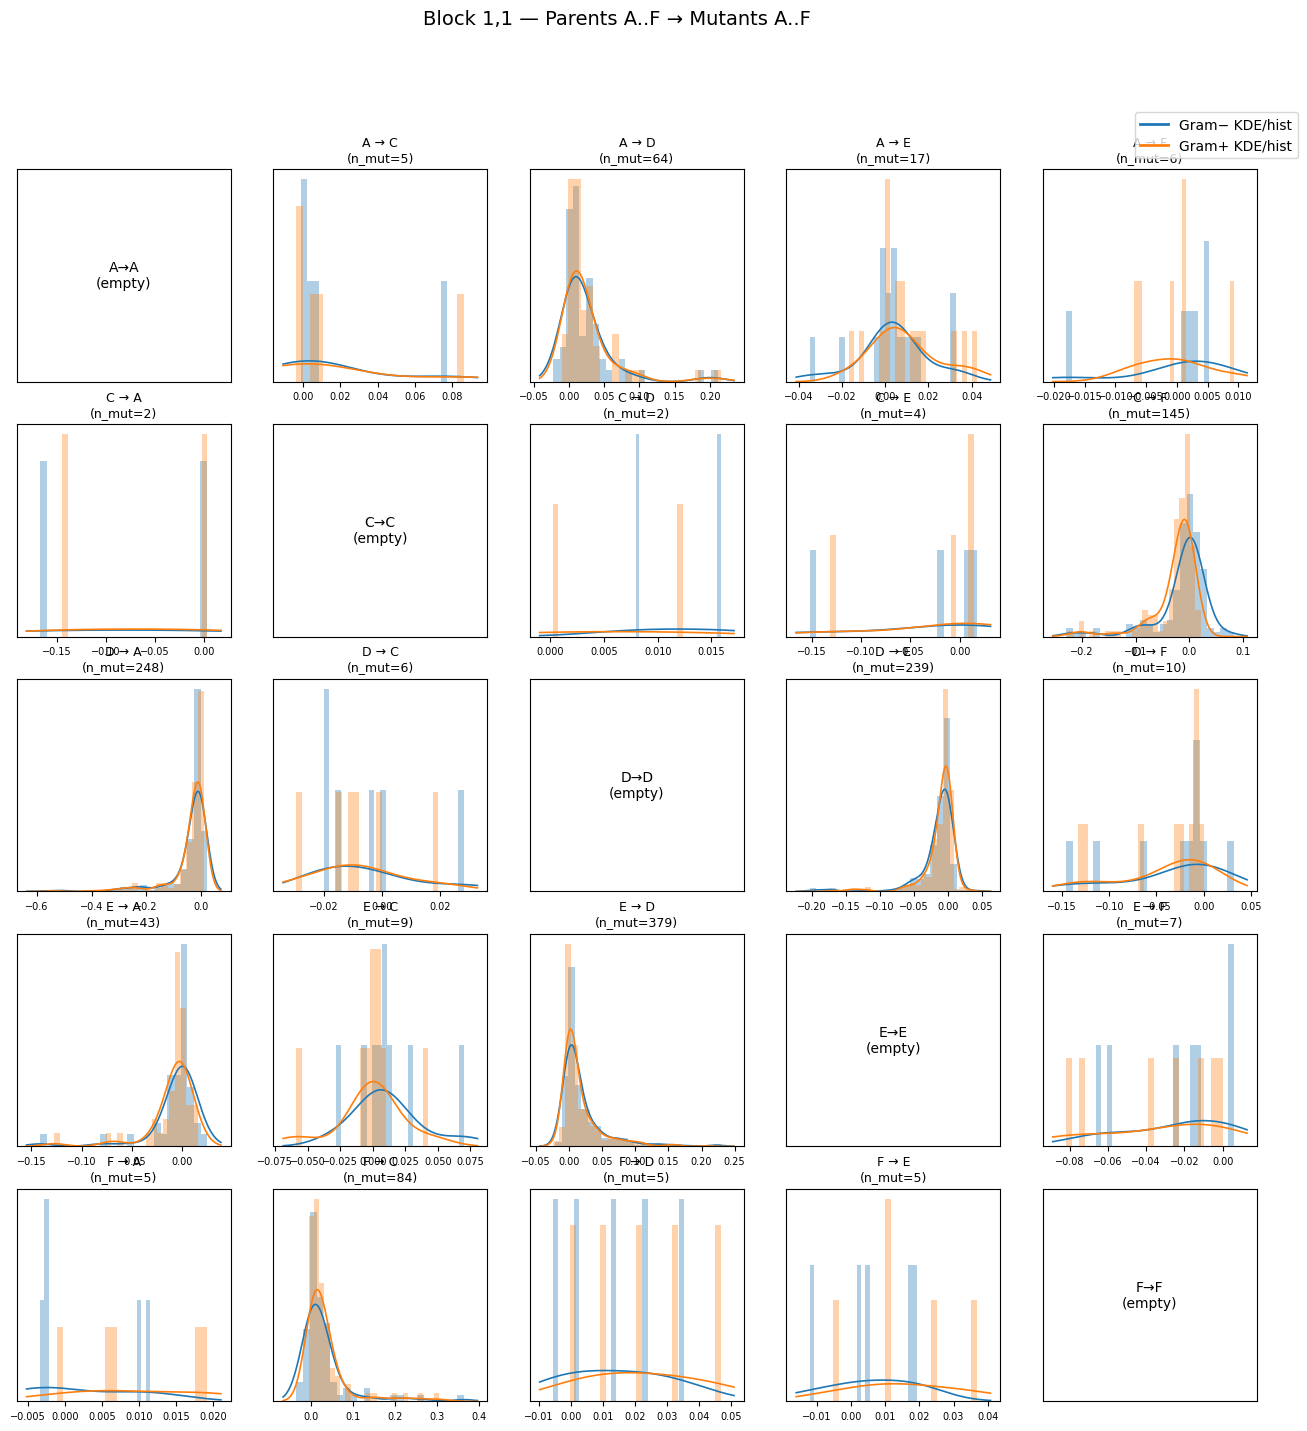

In [ ]:

n_bac = None
for p in ALL_AA:
    for m in ALL_AA:
        cell = mutation_matrix.at[p, m]
        if isinstance(cell, np.ndarray) and cell.size > 0:
            if cell.ndim == 2:
                n_bac = cell.shape[1]
                break
    if n_bac is not None:
        break

if n_bac is None:
    raise ValueError("Couldn't infer number of bacteria from mutation_matrix (all entries empty).")

print(f"Detected number of bacteria (columns) = {n_bac}")

# Validate Gram index lists (clip out-of-range indices and warn)
def validate_indices(name, idx_list):
    valid = [i for i in idx_list if 0 <= i < n_bac]
    removed = [i for i in idx_list if i not in valid]
    if removed:
        print(f"Warning: removed out-of-range indices from {name}: {removed}")
    if len(valid) == 0:
        raise ValueError(f"After validation, {name} is empty. Cannot proceed.")
    return valid

gram_neg = validate_indices("gram_neg", gram_neg)
gram_pos = validate_indices("gram_pos", gram_pos)

# prepare AA bins: 4 bins of 5 AA each
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]

# directory to save figures
outdir = "aa_block_plots_position_7"
os.makedirs(outdir, exist_ok=True)

# helper to compute per-mutation means for Gram groups robustly
def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    # If there are NaNs, nanmean will handle them
    try:
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        # in case arr has fewer cols than expected, return empty
        return np.array([])
    return means

# iterate over 4x4 blocks and build 5x5 plots per block
for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        fig.suptitle(f"Block {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        
        # Flatten axes for easy indexing
        axes_flat = axes.flatten()
        
        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                # get array for this pair
                arr = mutation_matrix.at[p_aa, m_aa]
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    # empty -> mark and continue
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # compute per-mutation means across gram groups
                gn = compute_group_means(arr, gram_neg)  # length = n_mutations
                gp = compute_group_means(arr, gram_pos)  # length = n_mutations
                
                # if both are empty (shouldn't happen) mark
                if gn.size == 0 and gp.size == 0:
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(no valid group data)", ha='center', va='center', fontsize=9)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # hist plotting parameters
                bins = 25
                alpha = 0.35
                # hist (density=True so KDE overlay aligns)
                if gn.size > 0:
                    ax.hist(gn, bins=bins, density=True, alpha=alpha, label="Gram−" if ax_idx==0 else None)
                if gp.size > 0:
                    ax.hist(gp, bins=bins, density=True, alpha=alpha, label="Gram+" if ax_idx==0 else None)
                
                # KDE overlays (only if at least 2 unique points)
                try:
                    if gn.size >= 2 and np.nanstd(gn) > 0:
                        kde_gn = gaussian_kde(gn)
                    else:
                        kde_gn = None
                except Exception:
                    kde_gn = None
                try:
                    if gp.size >= 2 and np.nanstd(gp) > 0:
                        kde_gp = gaussian_kde(gp)
                    else:
                        kde_gp = None
                except Exception:
                    kde_gp = None
                
                # build x-range from combined non-nan values
                combined_vals = np.concatenate([x for x in [gn, gp] if x.size>0])
                if combined_vals.size > 0:
                    xmin, xmax = np.nanmin(combined_vals), np.nanmax(combined_vals)
                    # extend a bit for nicer KDE tails
                    pad = (xmax - xmin) * 0.08 if xmax > xmin else 0.5
                    xs = np.linspace(xmin - pad, xmax + pad, 200)
                else:
                    xs = np.linspace(-1, 1, 200)
                
                if kde_gn is not None:
                    ax.plot(xs, kde_gn(xs), lw=1.2, color='tab:blue')
                if kde_gp is not None:
                    ax.plot(xs, kde_gp(xs), lw=1.2, color='tab:orange')
                
                # subplot title: single mutation pair
                ax.set_title(f"{p_aa} → {m_aa}\n(n_mut={arr.shape[0]})", fontsize=9)
                ax.tick_params(axis="x", labelsize=7)
                ax.set_yticks([])
        
        # Add a single legend to the figure (outside the grid)
        handles = []
        labels = []
        handles.append(plt.Line2D([0], [0], color='tab:blue', lw=2))
        labels.append('Gram− KDE/hist')
        handles.append(plt.Line2D([0], [0], color='tab:orange', lw=2))
        labels.append('Gram+ KDE/hist')
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.93, 0.92), fontsize=10)
        
        plt.tight_layout(rect=[0, 0, 0.92, 0.96])
        
        outpath = os.path.join(outdir, f"aa_block_{i_block+1}_{j_block+1}.png")
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")

In [17]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu # Import the nonparametric test

# Assuming ALL_AA, mutation_matrix, gram_neg, gram_pos are defined in the broader context

n_bac = None
for p in ALL_AA:
    for m in ALL_AA:
        cell = mutation_matrix.at[p, m]
        if isinstance(cell, np.ndarray) and cell.size > 0:
            if cell.ndim == 2:
                n_bac = cell.shape[1]
                break
    if n_bac is not None:
        break

if n_bac is None:
    raise ValueError("Couldn't infer number of bacteria from mutation_matrix (all entries empty).")

print(f"Detected number of bacteria (columns) = {n_bac}")

# Validate Gram index lists (clip out-of-range indices and warn)
def validate_indices(name, idx_list):
    valid = [i for i in idx_list if 0 <= i < n_bac]
    removed = [i for i in idx_list if i not in valid]
    if removed:
        print(f"Warning: removed out-of-range indices from {name}: {removed}")
    if len(valid) == 0:
        raise ValueError(f"After validation, {name} is empty. Cannot proceed.")
    return valid

# Assuming gram_neg and gram_pos indices lists are available
gram_neg = validate_indices("gram_neg", gram_neg)
gram_pos = validate_indices("gram_pos", gram_pos)

# prepare AA bins: 4 bins of 5 AA each
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]

# directory to save figures
outdir = "aa_scatters_position_7"
os.makedirs(outdir, exist_ok=True)

# helper to compute per-mutation means for Gram groups robustly
def compute_group_means(arr, gram_indices):
    """
    arr: np.ndarray shape (n_mutations, n_bacteria)
    gram_indices: list of column indices
    returns: 1D np.ndarray shape (n_mutations,) of mean across the specified bacteria
    """
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    try:
        if any(idx >= arr.shape[1] for idx in gram_indices):
             return np.array([])
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        return np.array([])
    return means

# iterate over 4x4 blocks and build 5x5 plots per block
for i_block, p_block in enumerate(AA_bins):
    for j_block, m_block in enumerate(AA_bins):
        fig, axes = plt.subplots(5, 5, figsize=(16, 16))
        # Updated suptitle to reflect the statistical test addition
        fig.suptitle(f"Scatter Plot & Mann-Whitney U Test p-values\nBlock {i_block+1},{j_block+1} — Parents {p_block[0]}..{p_block[-1]} → Mutants {m_block[0]}..{m_block[-1]}", fontsize=14)
        
        # Flatten axes for easy indexing
        axes_flat = axes.flatten()

        # --- Determine global plot limits (repeated from previous version) ---
        all_gn_gp_vals = []
        for p_aa in p_block:
            for m_aa in m_block:
                arr = mutation_matrix.at[p_aa, m_aa]
                if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0:
                    gn_data = compute_group_means(arr, gram_neg)
                    gp_data = compute_group_means(arr, gram_pos)
                    if gn_data.size > 0 and gp_data.size > 0:
                        valid_mask = np.isfinite(gn_data) & np.isfinite(gp_data)
                        all_gn_gp_vals.extend(gn_data[valid_mask])
                        all_gn_gp_vals.extend(gp_data[valid_mask])
        
        if all_gn_gp_vals:
            global_min = np.min(all_gn_gp_vals)
            global_max = np.max(all_gn_gp_vals)
            data_range = global_max - global_min if global_max > global_min else 1.0
            # limit_min = global_min - data_range * 0.05
            # limit_max = global_max + data_range * 0.05
            limit_min = -0.2
            limit_max = 0.2
        else:
            limit_min, limit_max = -0.1, 0.1 
        # --------------------------------------------------------------------
        
        for k, (p_aa) in enumerate(p_block):
            for l, (m_aa) in enumerate(m_block):
                ax_idx = k*5 + l
                ax = axes_flat[ax_idx]
                
                # get array for this pair
                arr = mutation_matrix.at[p_aa, m_aa]
                
                if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
                    # empty -> mark and continue
                    ax.text(0.5, 0.5, f"{p_aa}→{m_aa}\n(empty)", ha='center', va='center', fontsize=10)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    ax.set_title(f"{p_aa} → {m_aa}", fontsize=9)
                    continue
                
                # compute per-mutation means across gram groups
                gn = compute_group_means(arr, gram_neg)  # length = n_mutations
                gp = compute_group_means(arr, gram_pos)  # length = n_mutations
                
                # Filter out NaNs/Infs for plotting
                if gn.size > 0 and gp.size > 0:
                    valid_mask = np.isfinite(gn) & np.isfinite(gp)
                    gn_valid = gn[valid_mask]
                    gp_valid = gp[valid_mask]
                else:
                    gn_valid = np.array([])
                    gp_valid = np.array([])

                # --- Mann-Whitney U Test (Wilcoxon Rank-Sum) ---
                p_val_mw = np.nan
                u_stat_mw = np.nan
                test_label = "Insufficient data"
                
                # The Mann-Whitney U test compares the *two independent samples* (gn_data and gp_data) 
                # for the same set of N_mutations. 
                # This compares the distribution of all Gram-neg means against all Gram-pos means.
                # Crucially, the Mann-Whitney test should be applied to the original, full-size gn and gp arrays.
                
                # Re-check the full gn and gp (before paired filtering) for the test
                # Ensure we only use finite, non-zero-length arrays for the test
                gn_full = compute_group_means(arr, gram_neg)
                gp_full = compute_group_means(arr, gram_pos)
                
                # Clean the full arrays of NaNs/Infs before the test
                gn_clean = gn_full[np.isfinite(gn_full) & (gn_full.size > 0)]
                gp_clean = gp_full[np.isfinite(gp_full) & (gp_full.size > 0)]

                # Require at least a few points in each group to run the test robustly (e.g., 5)
                if gn_clean.size >= 5 and gp_clean.size >= 5:
                    try:
                        u_stat_mw, p_val_mw = mannwhitneyu(gn_clean, gp_clean, alternative='two-sided', method='auto')
                        
                        # Add significance stars for clarity
                        if p_val_mw < 0.001:
                            star = '***'
                        elif p_val_mw < 0.01:
                            star = '**'
                        elif p_val_mw < 0.05:
                            star = '*'
                        else:
                            star = 'ns'
                            
                        test_label = f"p={p_val_mw:.3f}{star} (n={gn_clean.size}, {gp_clean.size})"
                    except ValueError:
                        # Happens if all values are identical or if the sample is too small/degenerate for 'auto' method
                        test_label = f"Test Error (n={gn_clean.size}, {gp_clean.size})"
                    except Exception:
                        test_label = "Test Failed"
                
                # --- Scatter Plot continues ---
                if gn_valid.size == 0 or gp_valid.size == 0 or gn_valid.size != gp_valid.size:
                    title_text = f"{p_aa} → {m_aa}\n(no valid paired data)\nTest: {test_label}"
                    ax.text(0.5, 0.5, title_text, ha='center', va='center', fontsize=7)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    ax.set_title(f"{p_aa} → {m_aa}", fontsize=9)
                    continue

                # Scatter Plot (Gram-Neg mean on X, Gram-Pos mean on Y)
                ax.scatter(gn_valid, gp_valid, s=15, alpha=0.6, edgecolors='none', color='tab:green', label="Mutation Mean" if ax_idx==0 else None)
                
                # Add a 45-degree line (y=x) for comparison
                ax.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', alpha=0.5, lw=1)
                
                # Set consistent axes limits
                ax.set_xlim(limit_min, limit_max)
                ax.set_ylim(limit_min, limit_max)
                ax.set_aspect('equal', adjustable='box') 
                
                # Subplot title updated with test result
                title_text = f"{p_aa} → {m_aa} (n_pts={gn_valid.shape[0]})\nMWU: {test_label}"
                ax.set_title(title_text, fontsize=7)
                
                ax.tick_params(axis="both", labelsize=7)
                
                # Set X/Y labels only on the outside plots for clarity
                if k == 4: # Bottom row
                    ax.set_xlabel("Gram− Mean", fontsize=8)
                if l == 0: # Left column
                    ax.set_ylabel("Gram+ Mean", fontsize=8)
                else:
                    ax.tick_params(axis='y', labelleft=False)

        # Add a single legend to the figure (below the title)
        handles = []
        labels = []
        handles.append(plt.Line2D([0], [0], marker='o', color='tab:green', linestyle='', markersize=5, alpha=0.6))
        labels.append('Per-Mutation Mean (Gram+ vs Gram-)')
        handles.append(plt.Line2D([0], [0], color='k', linestyle='--', lw=1))
        labels.append('Y = X (No Difference)')
        
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=10)

        plt.tight_layout(rect=[0, 0, 1, 0.95]) 
        
        outpath = os.path.join(outdir, f"aa_position_7_scatter_{i_block+1}_{j_block+1}.png")
        plt.savefig(outpath, dpi=300)
        plt.close(fig)
        print(f"Saved: {outpath}")

Detected number of bacteria (columns) = 34


Saved: aa_scatters_position_7/aa_position_7_scatter_1_1.png
Saved: aa_scatters_position_7/aa_position_7_scatter_1_2.png
Saved: aa_scatters_position_7/aa_position_7_scatter_1_3.png
Saved: aa_scatters_position_7/aa_position_7_scatter_1_4.png
Saved: aa_scatters_position_7/aa_position_7_scatter_2_1.png
Saved: aa_scatters_position_7/aa_position_7_scatter_2_2.png
Saved: aa_scatters_position_7/aa_position_7_scatter_2_3.png
Saved: aa_scatters_position_7/aa_position_7_scatter_2_4.png
Saved: aa_scatters_position_7/aa_position_7_scatter_3_1.png
Saved: aa_scatters_position_7/aa_position_7_scatter_3_2.png
Saved: aa_scatters_position_7/aa_position_7_scatter_3_3.png
Saved: aa_scatters_position_7/aa_position_7_scatter_3_4.png
Saved: aa_scatters_position_7/aa_position_7_scatter_4_1.png
Saved: aa_scatters_position_7/aa_position_7_scatter_4_2.png
Saved: aa_scatters_position_7/aa_position_7_scatter_4_3.png
Saved: aa_scatters_position_7/aa_position_7_scatter_4_4.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- Zakładamy, że ALL_AA, mutation_matrix, gram_neg, gram_pos są już zdefiniowane ---

# Funkcja pomocnicza
def compute_group_means(arr, gram_indices):
    if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
        return np.array([])
    try:
        if any(idx >= arr.shape[1] for idx in gram_indices):
            return np.array([])
        means = np.nanmean(arr[:, gram_indices], axis=1)
    except Exception:
        return np.array([])
    return means


# --- GŁÓWNA CZĘŚĆ ---
pvals = []
pairs = []

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if not (isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.size > 0):
            continue

        gn = compute_group_means(arr, gram_neg)
        gp = compute_group_means(arr, gram_pos)

        if gn.size == 0 or gp.size == 0:
            continue

        # czyścimy dane
        gn_clean = gn[np.isfinite(gn)]
        gp_clean = gp[np.isfinite(gp)]

        # Wymagamy min. 5 wartości w każdej grupie
        if len(gn_clean) < 5 or len(gp_clean) < 5:
            continue

        try:
            u_stat, p_val = mannwhitneyu(
                gn_clean, gp_clean, alternative='two-sided', method='auto'
            )
        except Exception:
            continue

        pvals.append(p_val)
        pairs.append((p_aa, m_aa, gn_clean, gp_clean))

# --- WYBÓR 25 NAJMNIEJSZYCH p-value ---
if not pvals:
    raise ValueError("Brak danych — żaden test nie mógł być wykonany.")

sorted_idx = np.argsort(pvals)
top_idx = sorted_idx[:25]
top_pairs = [pairs[i] for i in top_idx]
top_pvals = [pvals[i] for i in top_idx]

print("\n🔍 Top 25 najmniejszych p-value (Mann–Whitney U):")
for rank, (p_aa, m_aa, _, _) in enumerate(top_pairs):
    print(f"{rank+1:2d}. {p_aa} → {m_aa}   p = {top_pvals[rank]:.3e}")

# --- TWORZENIE 5×5 WYKRESU ---
fig, axes = plt.subplots(5, 5, figsize=(16, 16))
fig.suptitle("Top 25 mutation pairs with lowest Mann–Whitney U p-value\n(Gram+ vs Gram− means)", fontsize=14)
axes_flat = axes.flatten()

# wspólny zakres osi
all_vals = np.concatenate([np.concatenate([gn, gp]) for _, _, gn, gp in top_pairs])
limit_min, limit_max = np.percentile(all_vals, [1, 99])
padding = (limit_max - limit_min) * 0.1
limit_min -= padding
limit_max += padding

for ax, (p_aa, m_aa, gn, gp) in zip(axes_flat, top_pairs):
    valid_mask = np.isfinite(gn) & np.isfinite(gp)
    gn_valid = gn[valid_mask]
    gp_valid = gp[valid_mask]

    ax.scatter(gn_valid, gp_valid, s=15, alpha=0.6, color='tab:green', edgecolors='none')
    ax.plot([limit_min, limit_max], [limit_min, limit_max], 'k--', alpha=0.5, lw=1)

    ax.set_xlim(limit_min, limit_max)
    ax.set_ylim(limit_min, limit_max)
    ax.set_aspect('equal', adjustable='box')

    # podpis p-value z gwiazdkami
    pval = mannwhitneyu(gn_valid, gp_valid, alternative='two-sided', method='auto').pvalue
    if pval < 0.001:
        star = "***"
    elif pval < 0.01:
        star = "**"
    elif pval < 0.05:
        star = "*"
    else:
        star = "ns"

    ax.set_title(f"{p_aa}→{m_aa}\np={pval:.1e} {star}", fontsize=9)
    ax.tick_params(axis='both', labelsize=7)

for ax in axes_flat[len(top_pairs):]:
    ax.axis("off")

fig.text(0.5, 0.04, "Gram− Mean", ha="center", fontsize=12)
fig.text(0.04, 0.5, "Gram+ Mean", va="center", rotation="vertical", fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# --- zapis + pokazanie ---
outdir = "aa_top25_mannwhitney"
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "top25_scatter_mannwhitney.png")
plt.savefig(outfile, dpi=300)
plt.show()

print(f"\n✅ Zapisano wykres do pliku: {outfile}")


In [46]:
from scipy.stats import shapiro
import numpy as np

passes_pos = 0
fails_pos = 0
passes_neg = 0
fails_neg = 0
tested_pos = 0
tested_neg = 0

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        gn, gp = gram_means.at[p_aa, m_aa]
        # Gram-negative test
        if isinstance(gn, np.ndarray) and gn.size >= 3:  # Shapiro requires n>=3
            tested_neg += 1
            stat, pval = shapiro(gn)
            if pval >= 0.01:
                passes_neg += 1
            else:
                fails_neg += 1
        # Gram-positive test
        if isinstance(gp, np.ndarray) and gp.size >= 3:
            tested_pos += 1
            stat, pval = shapiro(gp)
            if pval >= 0.05:
                passes_pos += 1
            else:
                fails_pos += 1

print("📊 Shapiro–Wilk Normality Test Results:")
print(f"Gram−  →  passed: {passes_neg} / {tested_neg}  ({passes_neg/tested_neg:.1%})")
print(f"Gram+  →  passed: {passes_pos} / {tested_pos}  ({passes_pos/tested_pos:.1%})")


📊 Shapiro–Wilk Normality Test Results:
Gram−  →  passed: 127 / 356  (35.7%)
Gram+  →  passed: 95 / 356  (26.7%)


In [47]:
from scipy.stats import shapiro, skew, kurtosis, gaussian_kde
import numpy as np

# Optional: dip test for multimodality (requires package 'diptest')
try:
    from diptest import diptest
    has_diptest = True
except ImportError:
    has_diptest = False
    print("⚠️ diptest not installed, using kurtosis heuristic for bimodality")

results = []

for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        gn, gp = gram_means.at[p_aa, m_aa]
        for label, arr in [("Gram−", gn), ("Gram+", gp)]:
            if isinstance(arr, np.ndarray) and arr.size >= 3:
                arr = arr[np.isfinite(arr)]
                if len(arr) < 3:
                    continue

                # --- 1. Shapiro–Wilk normality test ---
                try:
                    stat, p_norm = shapiro(arr)
                except Exception:
                    p_norm = np.nan

                # --- 2. Bimodality detection ---
                if has_diptest:
                    try:
                        dip, p_dip = diptest(arr)
                    except Exception:
                        p_dip = np.nan
                else:
                    # Heuristic: high kurtosis (>3) and skew near 0 → possibly bimodal
                    k = kurtosis(arr, fisher=False)
                    p_dip = 1.0 if (k < 2.5 or k > 4.5) else 0.01

                # --- 3. Skewness & kurtosis ---
                sk = skew(arr)
                k = kurtosis(arr, fisher=False)

                results.append({
                    "pair": f"{p_aa}->{m_aa}",
                    "group": label,
                    "n": len(arr),
                    "p_normal": p_norm,
                    "p_bimodal": p_dip,
                    "skew": sk,
                    "kurtosis": k
                })

results_df = pd.DataFrame(results)

# --- Summary statistics ---
normal_pass = (results_df["p_normal"] >= 0.01).sum()
normal_fail = (results_df["p_normal"] < 0.01).sum()

bimodal_pass = (results_df["p_bimodal"] < 0.01).sum()  # likely bimodal
skewed = (np.abs(results_df["skew"]) > 1).sum()
heavy_tailed = (results_df["kurtosis"] > 4).sum()

print("📊 Distribution Shape Summary")
print(f"Normal-like distributions (p≥0.01): {normal_pass}/{len(results_df)}")
print(f"Non-normal distributions (p<0.01): {normal_fail}/{len(results_df)}")
print(f"Likely bimodal (Dip/kurtosis): {bimodal_pass}/{len(results_df)}")
print(f"Strongly skewed (|skew|>1): {skewed}/{len(results_df)}")
print(f"Heavy-tailed (kurtosis>4): {heavy_tailed}/{len(results_df)}")

# Optional: view the worst offenders
print("\n🔍 Most bimodal examples:")
print(results_df.sort_values("p_bimodal").head(10)[["pair", "group", "p_bimodal", "skew", "kurtosis"]])


⚠️ diptest not installed, using kurtosis heuristic for bimodality
📊 Distribution Shape Summary
Normal-like distributions (p≥0.01): 254/712
Non-normal distributions (p<0.01): 458/712
Likely bimodal (Dip/kurtosis): 0/712
Strongly skewed (|skew|>1): 495/712
Heavy-tailed (kurtosis>4): 428/712

🔍 Most bimodal examples:
     pair  group  p_bimodal      skew  kurtosis
0    A->C  Gram−       0.01  1.470086  3.210693
566  S->R  Gram−       0.01  1.035876  3.332392
561  S->N  Gram+       0.01 -1.074470  2.623891
198  G->P  Gram−       0.01  0.757338  2.840084
559  S->M  Gram+       0.01  0.796229  2.868950
404  N->H  Gram−       0.01  0.587569  2.572744
202  G->R  Gram−       0.01 -1.121429  3.513234
555  S->K  Gram+       0.01 -1.154469  3.042111
554  S->K  Gram−       0.01 -1.131830  3.063804
553  S->I  Gram+       0.01 -1.054561  2.766145


In [5]:
def create_square_plot(
    data: np.ndarray,
    classification: str | None = None,
    cmap: str = "coolwarm",
    title: str | None = None,
    show_labels: bool = True,
    figsize=(10, 8),
    return_fig: bool | None = None,
    ax: plt.Axes | None = None,   # ✅ Optional axis
    vmin: float | None = None,    # ✅ New
    vmax: float | None = None,    # ✅ New
):
    """
    Create a sorted amino acid × amino acid heatmap based on a chosen classification.

    If `ax` is provided, the plot will be drawn on that axis instead of creating a new figure.
    """
    data = np.asarray(data, dtype=float)
    n = data.shape[0]
    if data.shape[0] != data.shape[1]:
        raise ValueError("Input data must be a square matrix!")

    aas = ALL_AA if n == 20 else [f"AA{i+1}" for i in range(n)]
    df = pd.DataFrame(data, index=aas, columns=aas)

    # Create figure/axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = plt.gcf()

    # === Case 1: no classification ===
    if classification is None:
        sns.heatmap(df, cmap=cmap, square=True, cbar=True, ax=ax,
                    vmin=vmin, vmax=vmax)
        if not title:
            title = "Amino acid × amino acid (unsorted)"
        ax.set_title(title, fontsize=14)
        # ax.set_xlabel("Amino acid")
        # ax.set_ylabel("Amino acid")
        plt.tight_layout()
        if return_fig:
            return fig, ax
        else:
            return None

    # === Case 2: classification selected ===
    if classification not in AMINO_ACID_CLASSES:
        raise ValueError(f"Unknown classification: {classification}")

    groups = AMINO_ACID_CLASSES[classification]
    sorted_groups = list(groups.keys())

    sorted_aas = [aa for group in sorted_groups for aa in aas if aa in groups[group]]
    missing = [aa for aa in aas if aa not in sorted_aas]
    sorted_aas.extend(missing)

    df_sorted = df.loc[sorted_aas, sorted_aas]

    # ✅ Apply vmin/vmax if provided
    sns.heatmap(df_sorted, cmap=cmap, square=True, cbar=True, ax=ax,
                vmin=vmin, vmax=vmax)

    if not title:
        title = f" Mutational signatures ({classification} classification)"
    ax.set_title(title, fontsize=14)
    # ax.set_xlabel("Amino acid")
    # ax.set_ylabel("Amino acid")

    # === Group boundaries and labels ===
    group_sizes = [len(groups[g]) for g in sorted_groups if any(aa in aas for aa in groups[g])]
    boundaries = np.cumsum(group_sizes)

    for b in boundaries[:-1]:
        ax.axhline(b, color="black", lw=1)
        ax.axvline(b, color="black", lw=1)

    if show_labels:
        midpoints = np.array(boundaries) - np.array(group_sizes) / 2
        for i, g in enumerate(sorted_groups):
            mid = midpoints[i]
            ax.text(-1.5, mid, g, va="center", ha="right", fontsize=10)
        ylim = ax.get_ylim()
        xlim = ax.get_xlim()
        offset = len(aas) * 0.05
        for i, g in enumerate(sorted_groups):
            mid = midpoints[i]
            ax.text(mid, len(aas) + offset, g, va="top", ha="center", fontsize=10)
        ax.set_ylim(ylim)
        ax.set_xlim(xlim)

    plt.tight_layout()
    if return_fig:
        return fig, ax
    else:
        return None


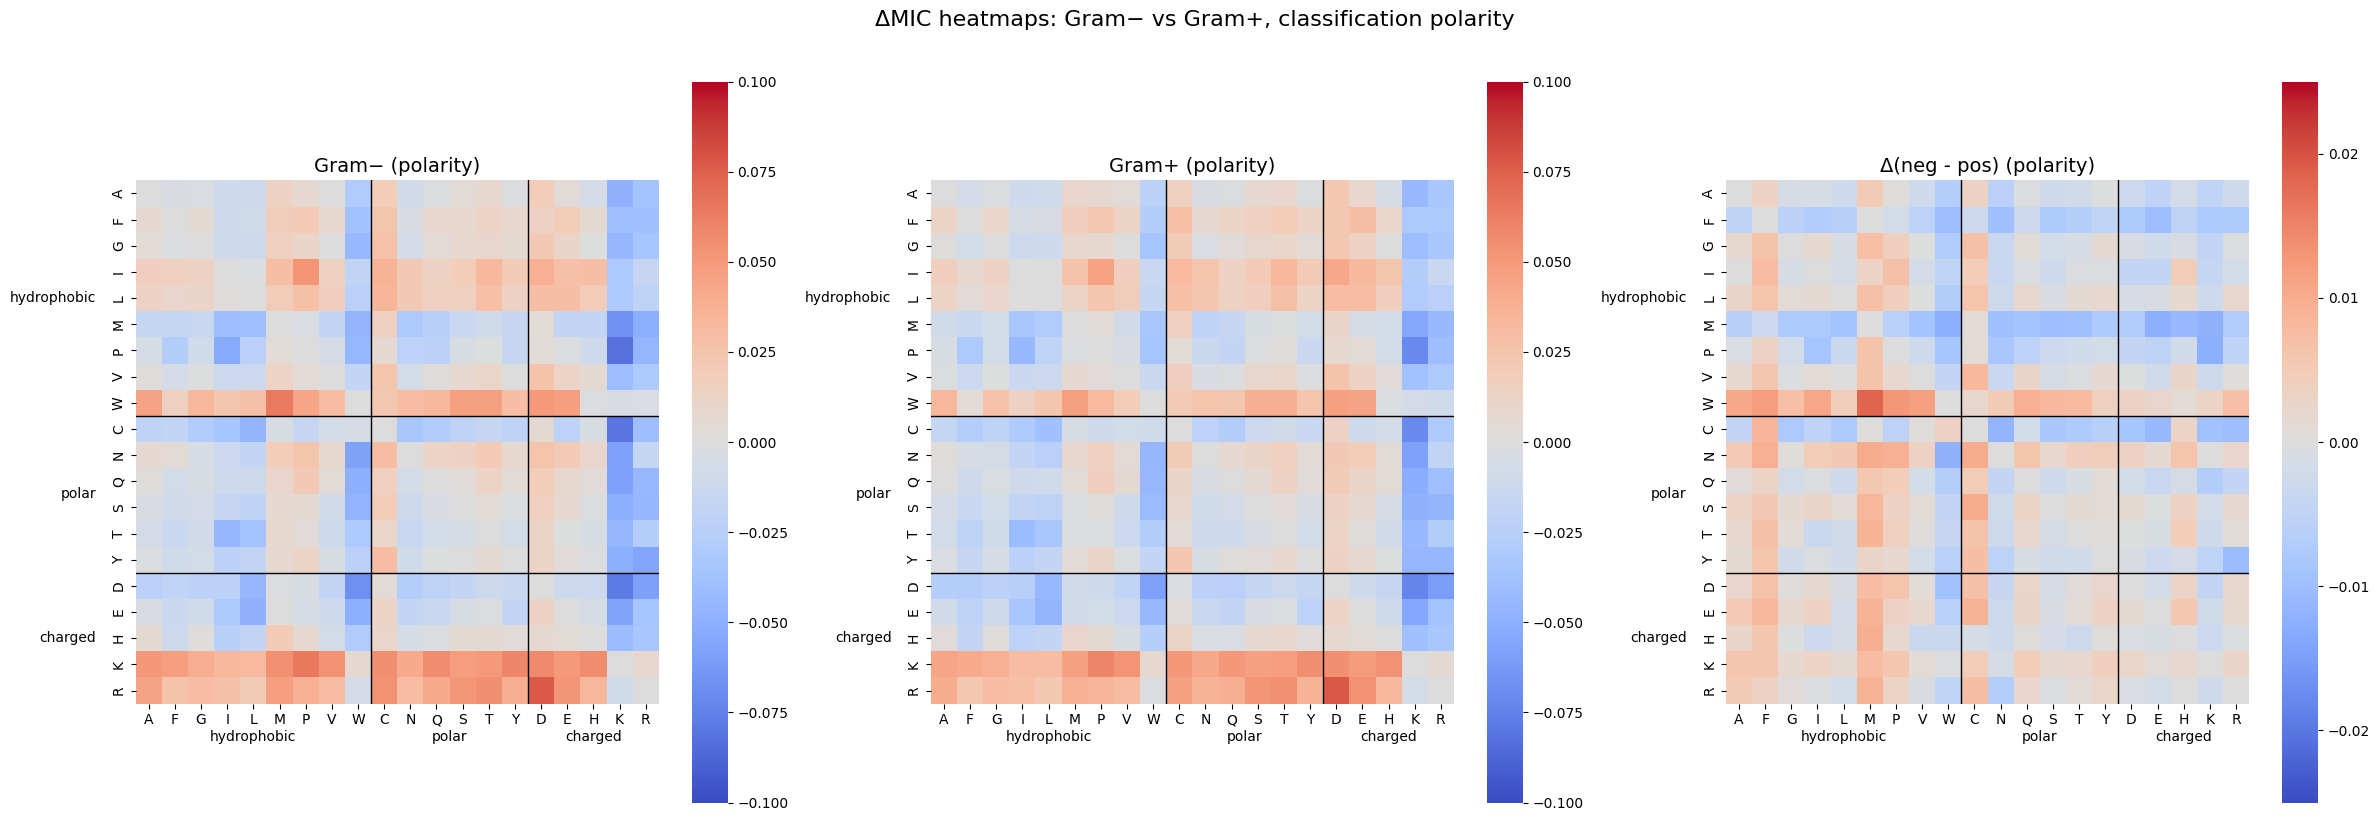

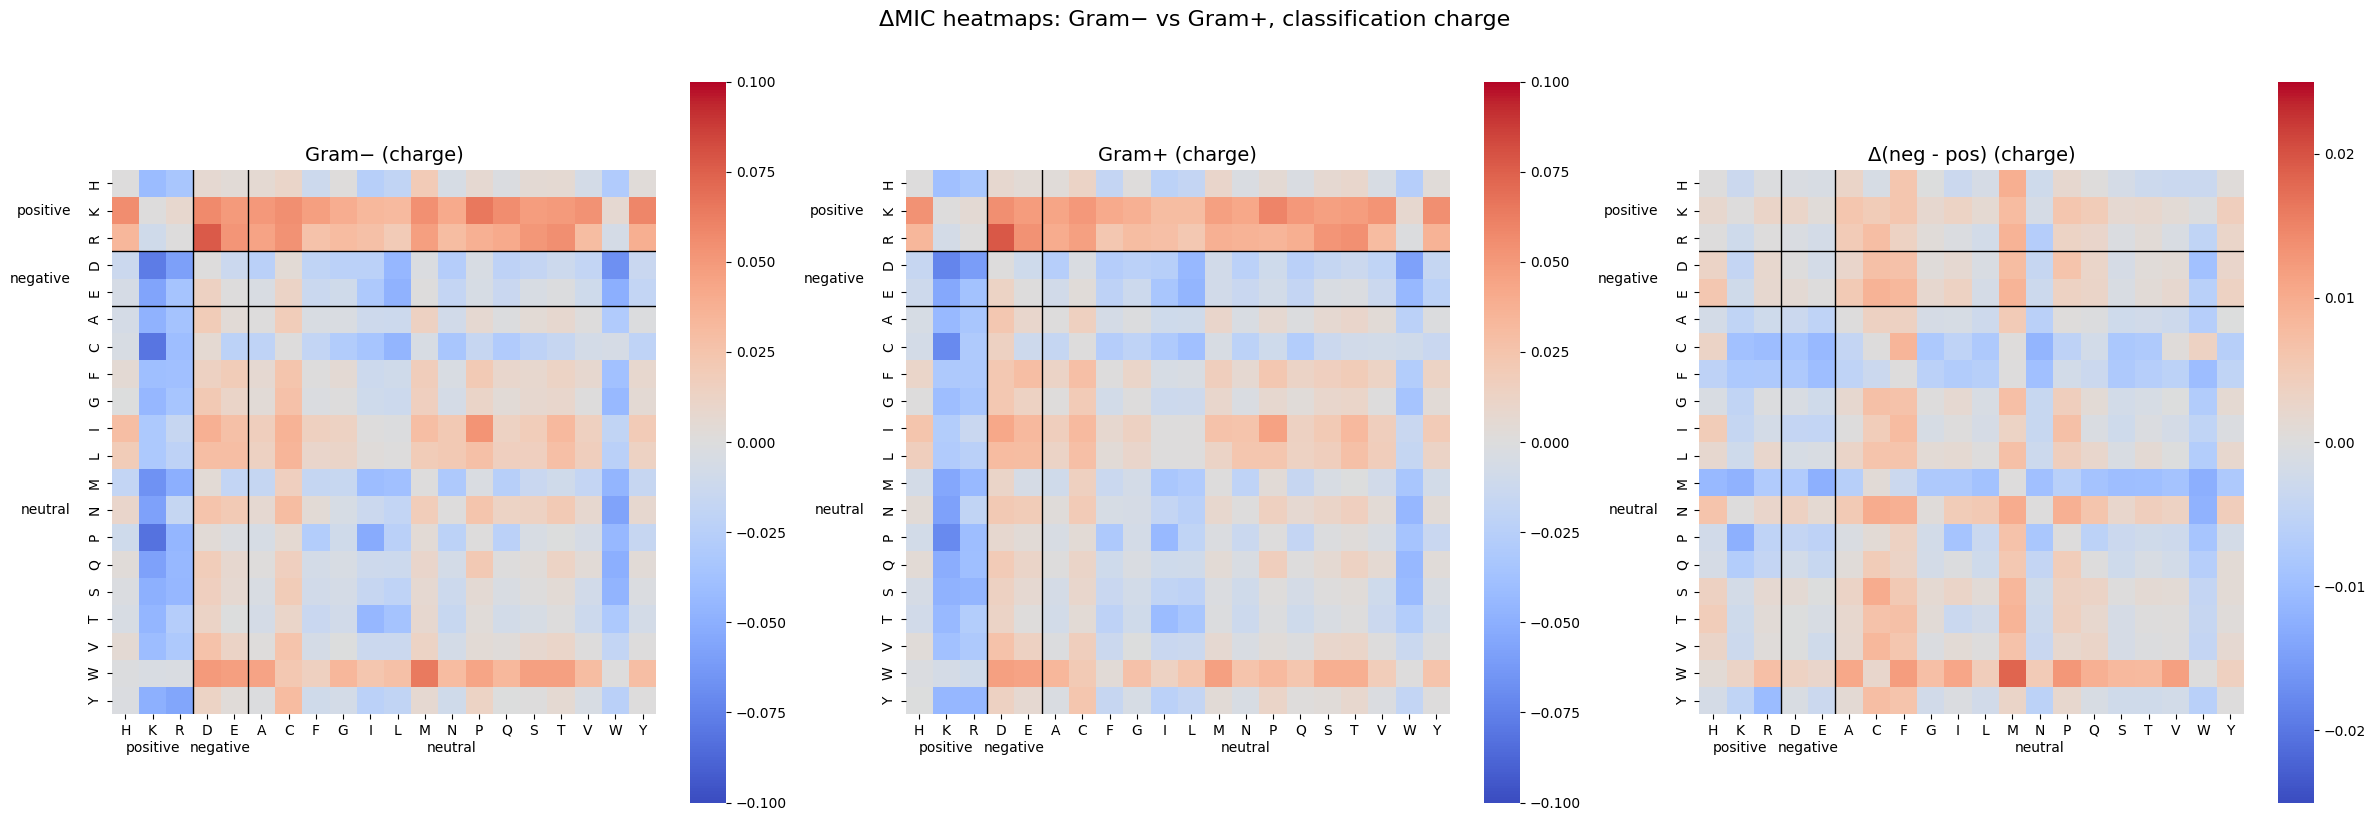

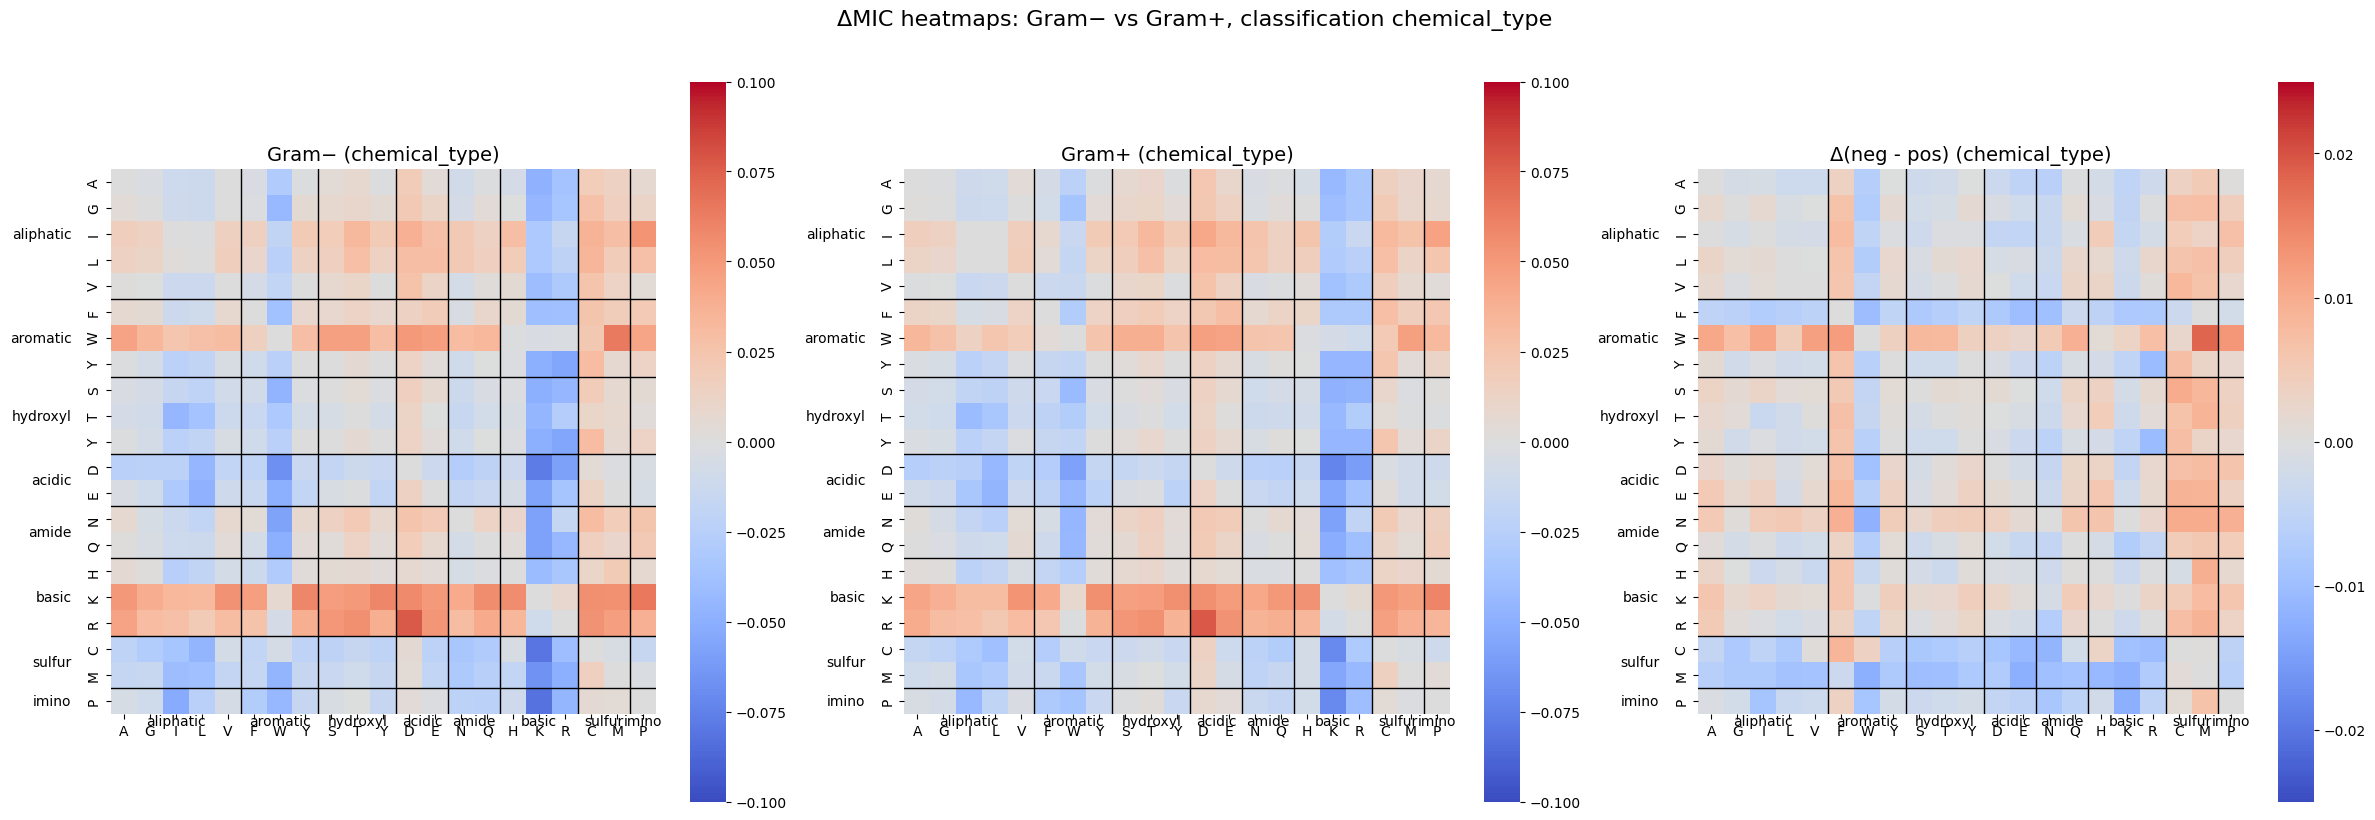

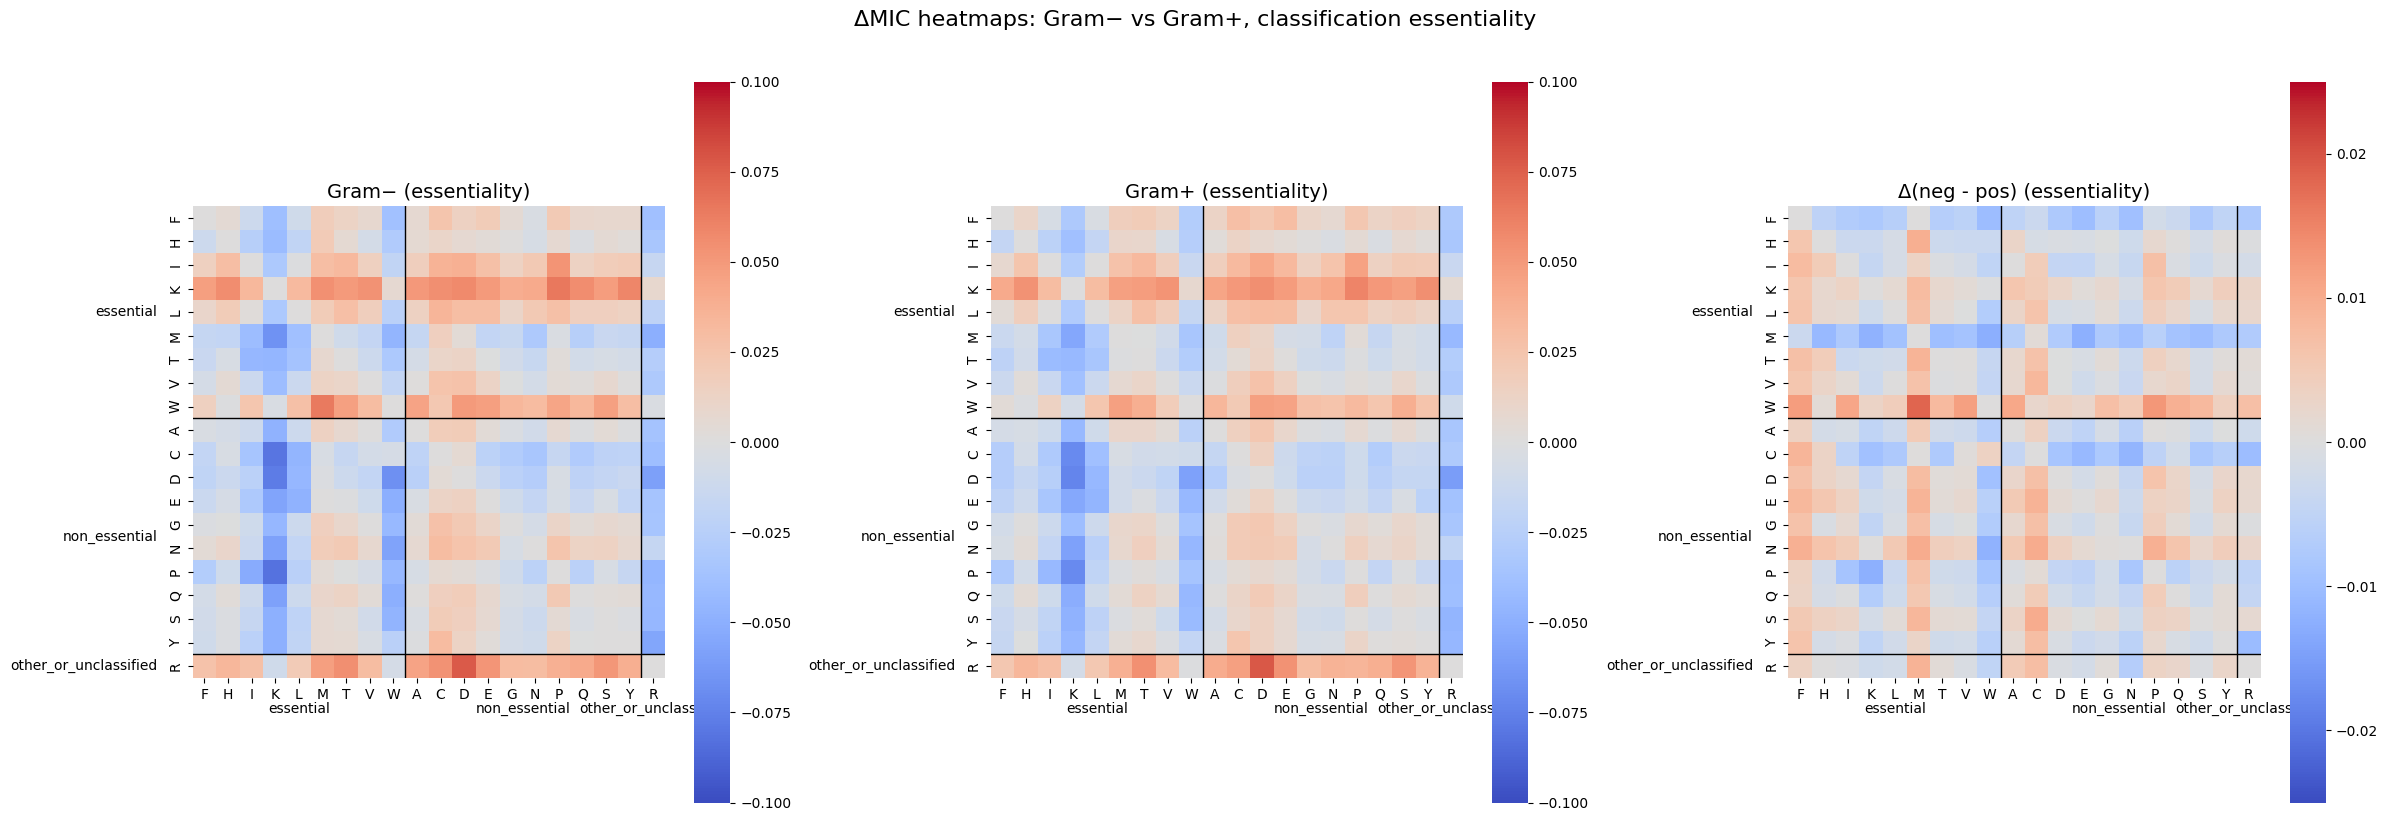

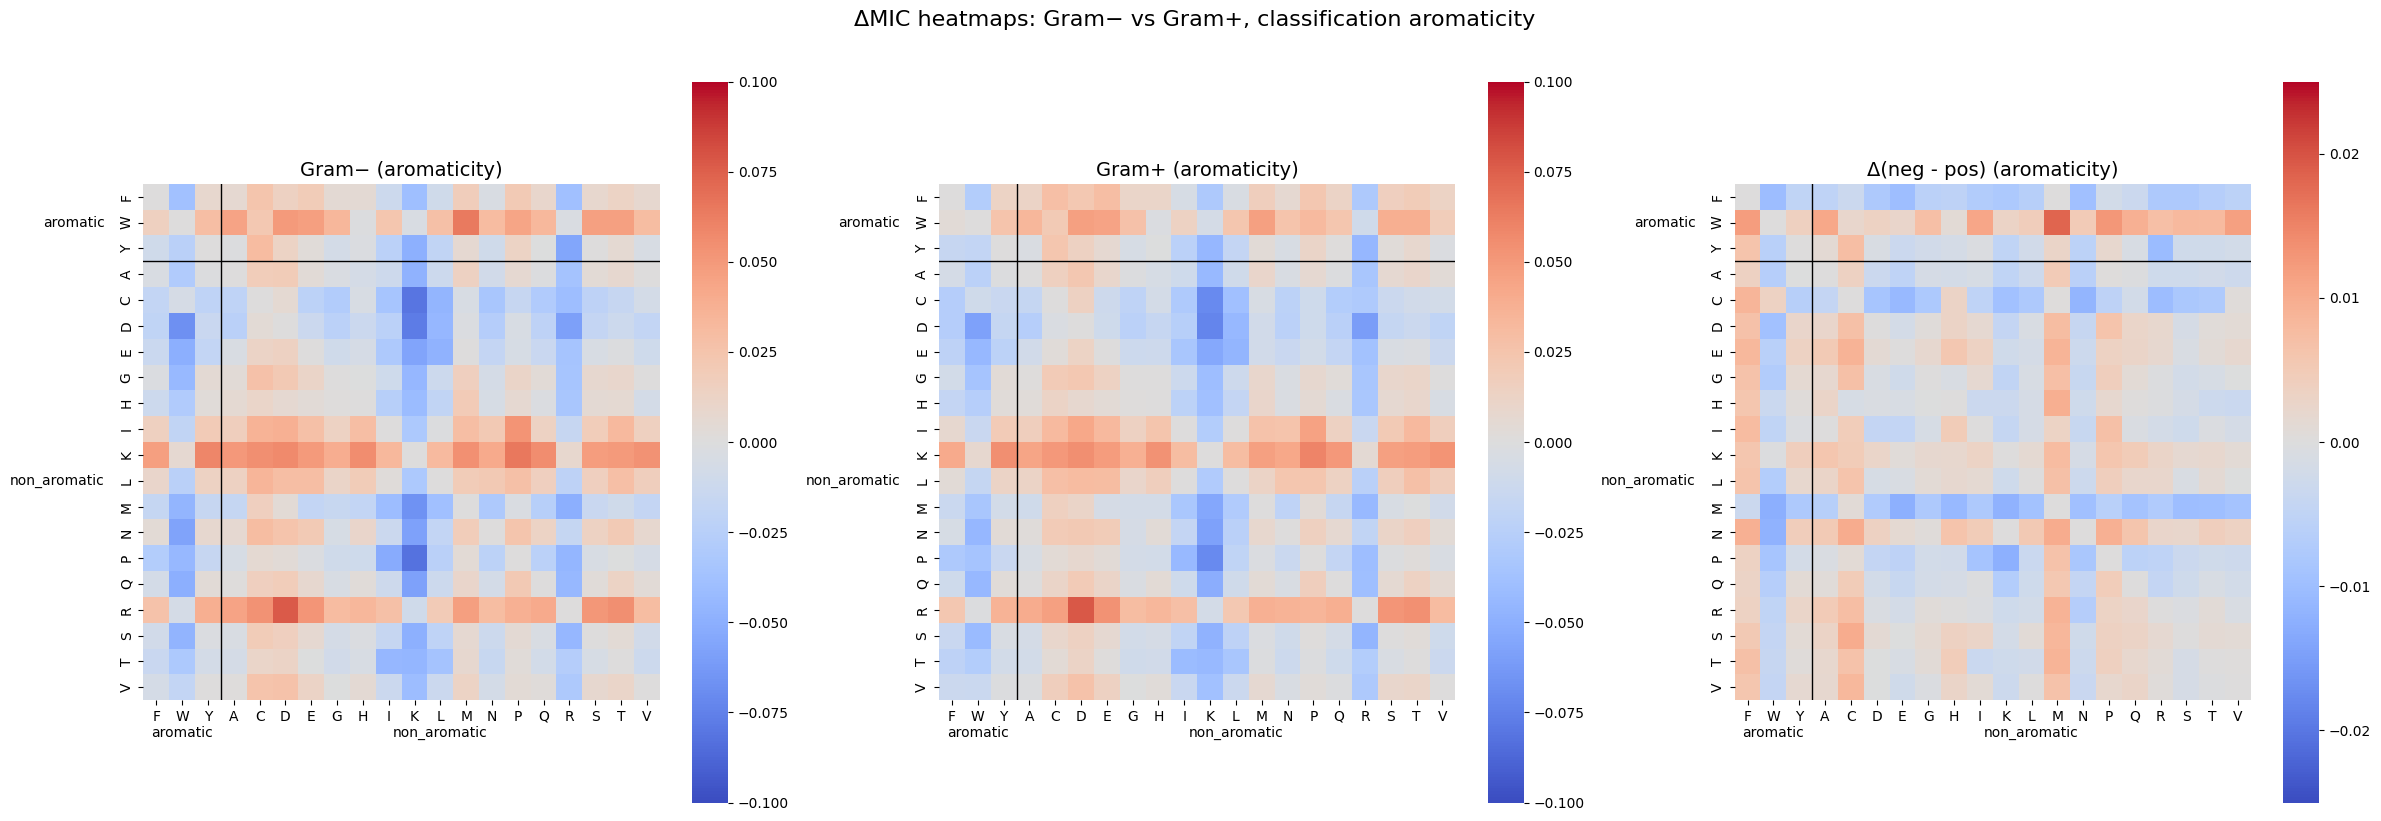

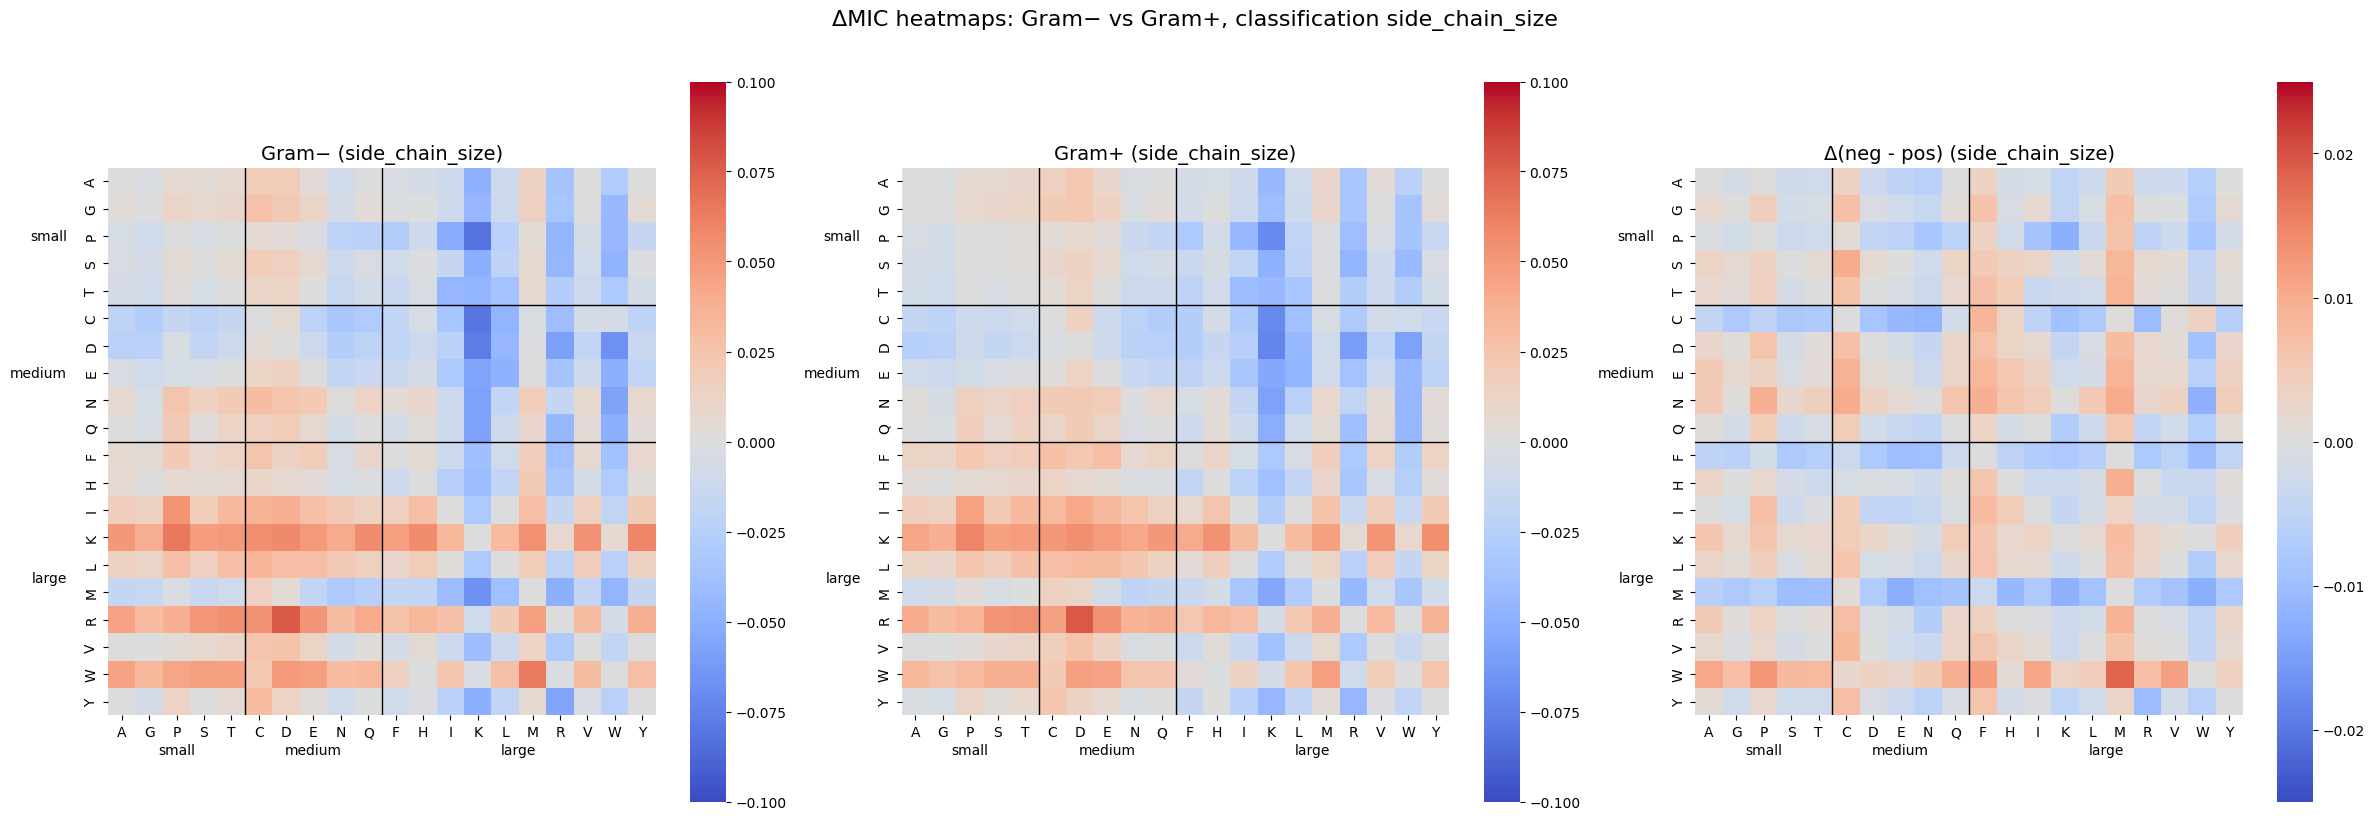

In [ ]:
colors = [(0, "green"), (0.5, "white"), (1, "red")]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("greenwarm", colors)


for c in classes:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

    # Draw on given axes instead of creating new ones
    create_square_plot(
        mean_gram_neg_matrix.astype(float),
        classification=c,
        title=f"Gram− ({c})",
        ax=ax1,
        show_labels=True,
        return_fig=False,
        vmin = -0.1,
        vmax = 0.1,
        cmap=custom_cmap

    )

    create_square_plot(
        mean_gram_pos_matrix.astype(float),
        classification=c,
        title=f"Gram+ ({c})",
        ax=ax2,
        show_labels=True,
        return_fig=False,
        vmin = -0.1,
        vmax = 0.1,
        cmap=custom_cmap
    )
    
    difference_matrix = mean_gram_neg_matrix - mean_gram_pos_matrix

    create_square_plot(
        difference_matrix.astype(float),
        classification=c,
        title=f"Δ(neg - pos) ({c})",
        ax=ax3,
        show_labels=True,
        return_fig=False,
        vmin=-0.025,
        vmax=0.025,
        cmap=custom_cmap
    )

    fig.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification {c}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


TOP LAST 7

In [21]:



def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

mic_bac_columns = parents.head().columns.tolist()[2:]

diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="Name",
    match_col_mutants="parent_name",
    value_cols=mic_bac_columns,
    value_preprocessing="log",
    add_relative=True,
)


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

#possition mask (take only mutations on first/last 7 positions)0

position_mask = (
    (diff_clean["position"] < 7) |
    (diff_clean["position"] >= diff_clean["parent"].str.len() - 7)
    )
diff_clean = diff_clean[position_mask]



delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()


# Prepare empty mean matrix

mean_diffs_matrix = pd.DataFrame(
    [[None for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

# Compute mean ΔMIC per mutation cell
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vectors = mutation_matrix.at[p_aa, m_aa]  # list of ΔMIC vectors
        if len(vectors) > 0:
            mean_diffs_matrix.at[p_aa, m_aa] = np.mean(vectors, axis=0)  # mean per bacterium
        else:
            mean_diffs_matrix.at[p_aa, m_aa] = np.zeros(len(delta_cols))  # or np.nan

gram_neg = [0,1,2,3,4,5,6,11,12,13,16,17,18,19,20,22,23,24,29,30,31,32]
gram_pos = [7,8,9,10,14,15,21,25,26,27,28,33]

##having mutation_matrix, make histogram plot of mean values for gram_pos and gram_neg for each entry of mutation matrix
gram_means = pd.DataFrame(index=ALL_AA, columns=ALL_AA, dtype=object)
AA_bins = [ALL_AA[i:i+5] for i in range(0, 20, 5)]
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        arr = mutation_matrix.at[p_aa, m_aa]
        if isinstance(arr, np.ndarray) and arr.size > 0 and arr.ndim == 2:
            # mean over bacteria within each group → one value per mutation
            gram_neg_means = np.nanmean(arr[:, gram_neg], axis=1)
            gram_pos_means = np.nanmean(arr[:, gram_pos], axis=1)
            gram_means.at[p_aa, m_aa] = (gram_neg_means, gram_pos_means)
        else:
            gram_means.at[p_aa, m_aa] = ([], [])


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# mean_diffs_matrix: each cell = np.array of ΔMIC means (length 34)

# Prepare matrices for mean MIC change per group
mean_gram_neg_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)
mean_gram_pos_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)

# Compute group means
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vector = mean_diffs_matrix.at[p_aa, m_aa]
        if vector is not None and isinstance(vector, (list, np.ndarray)) and len(vector) > 0:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_neg if i < len(vector)])
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_pos if i < len(vector)])
        else:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nan
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nan


# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)



AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



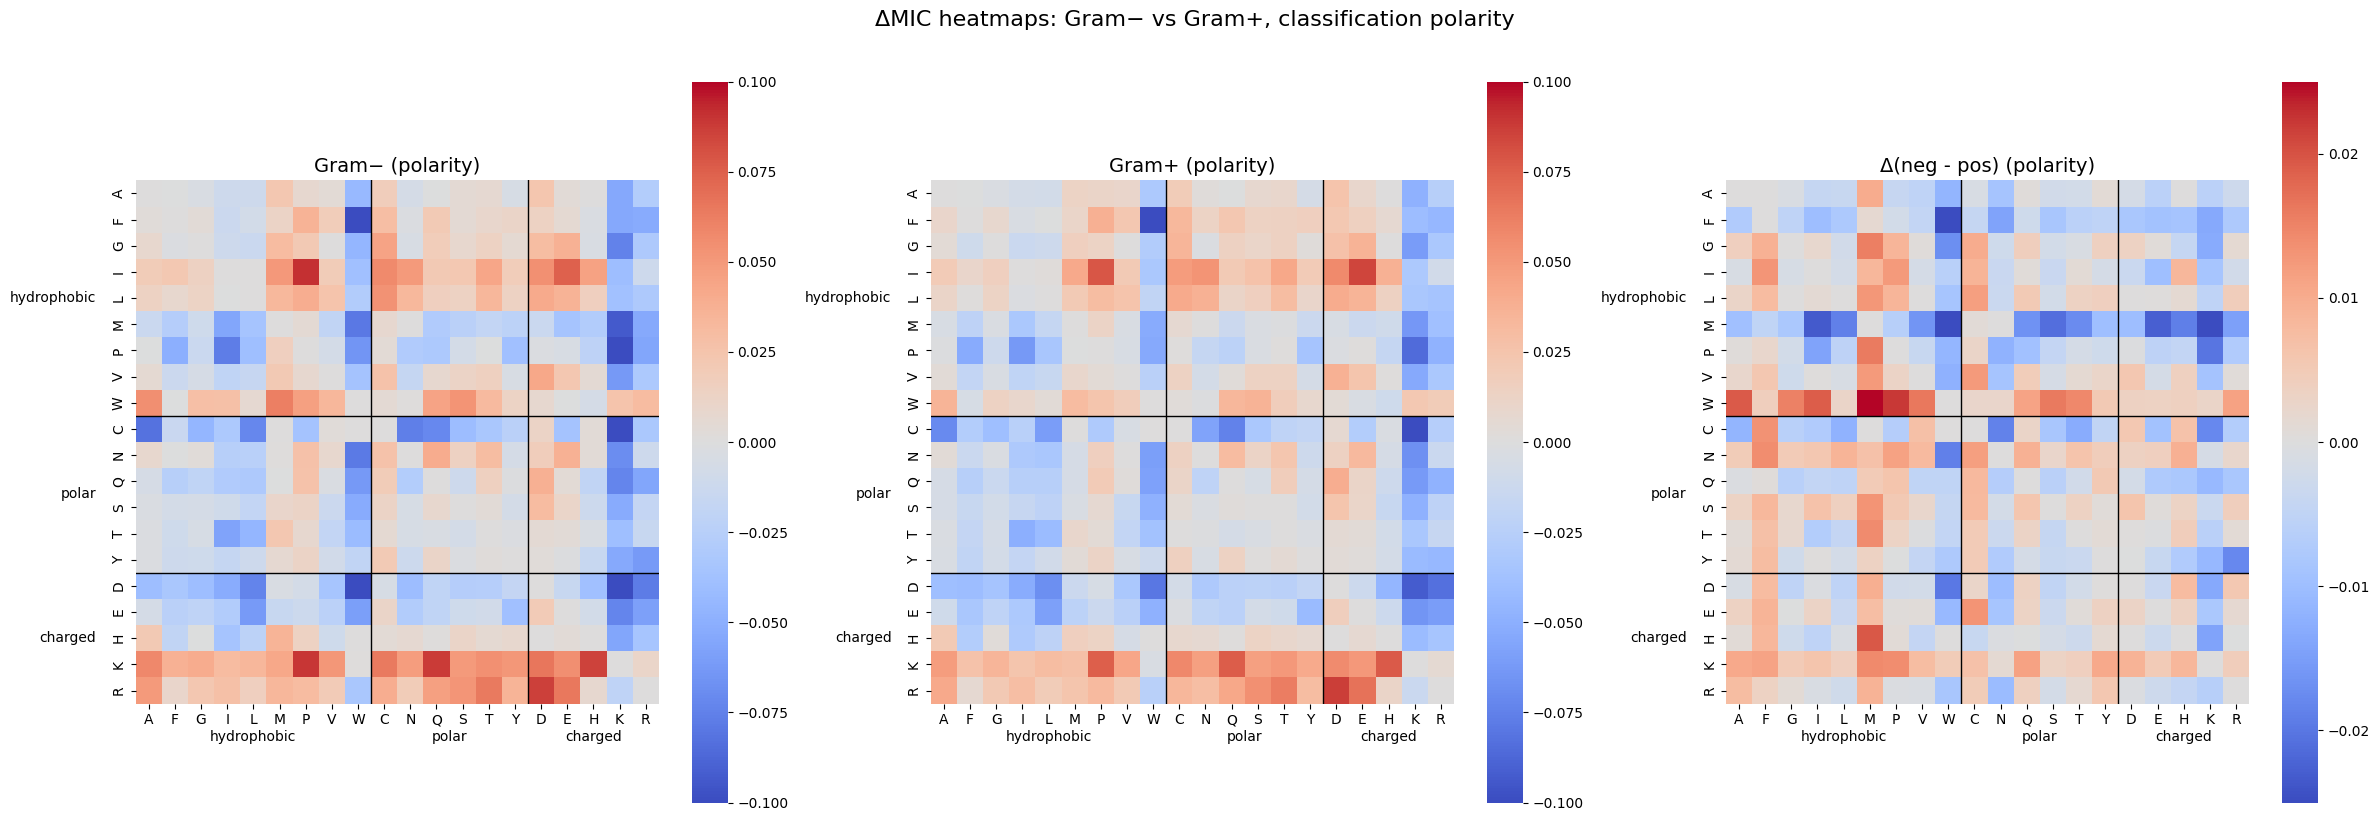

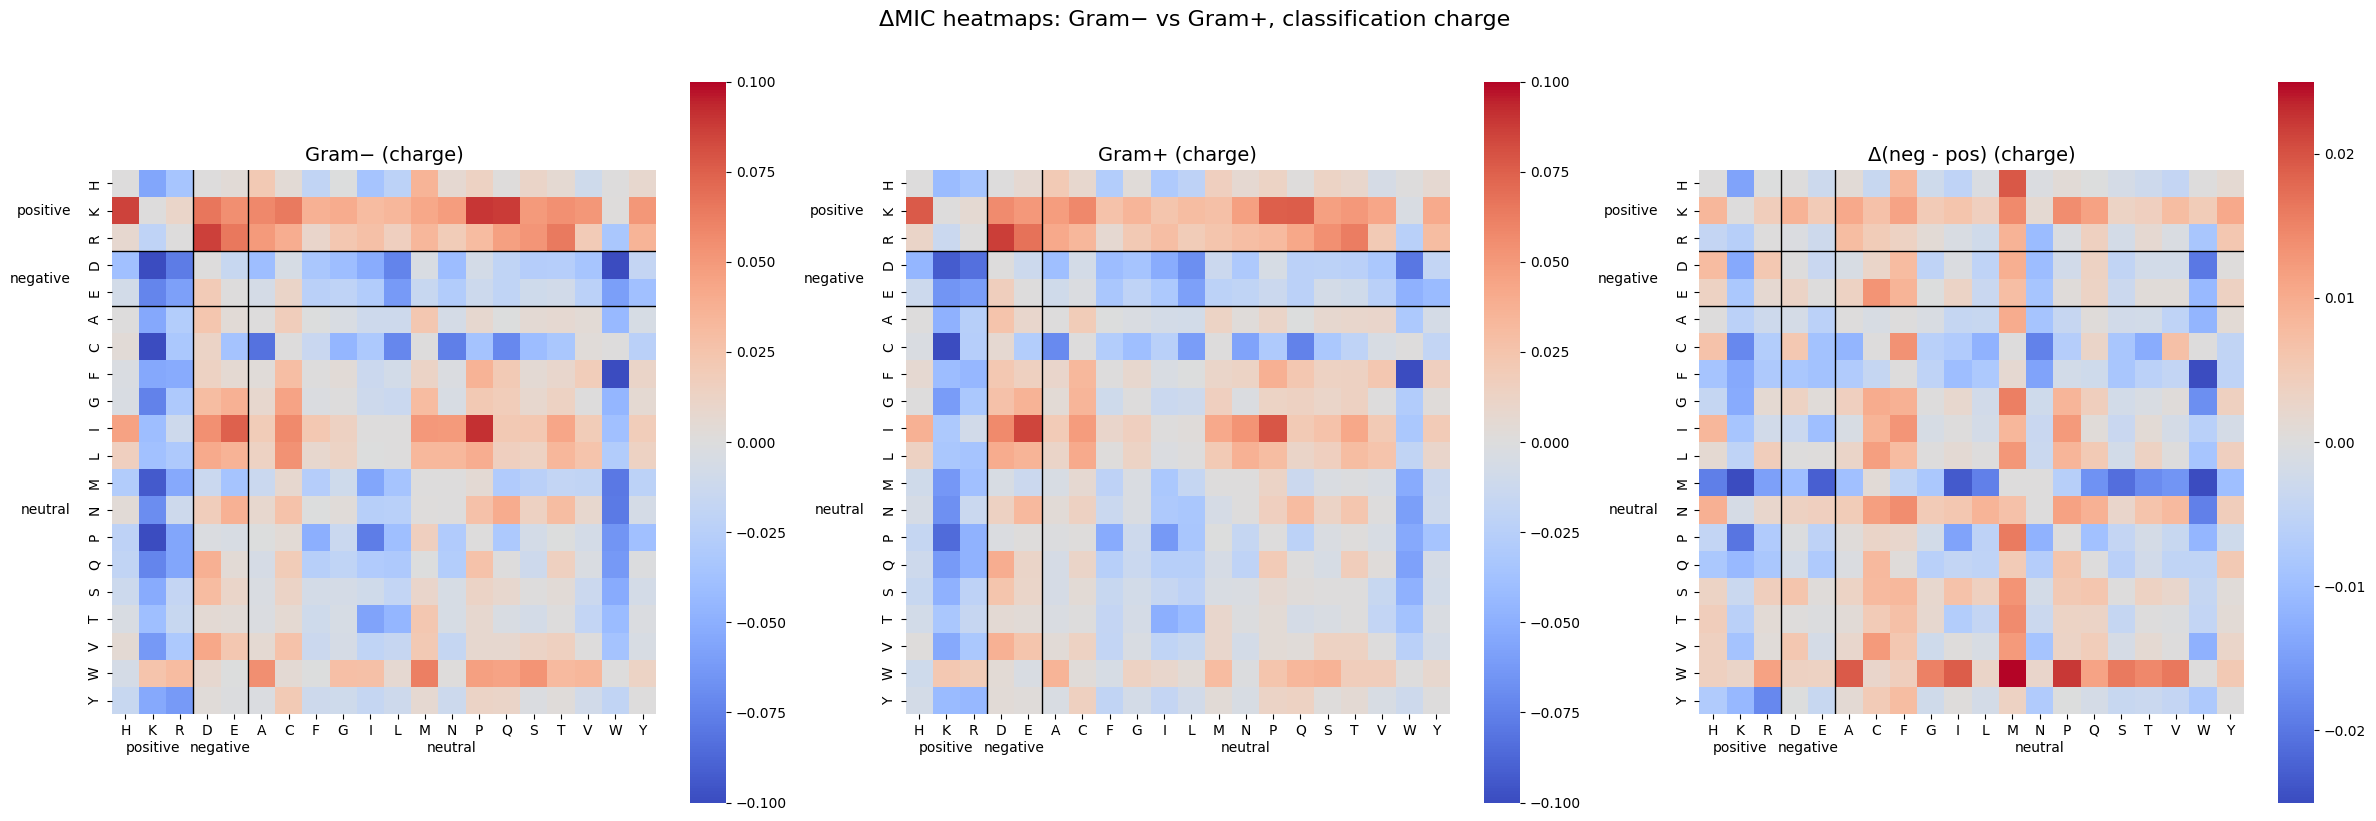

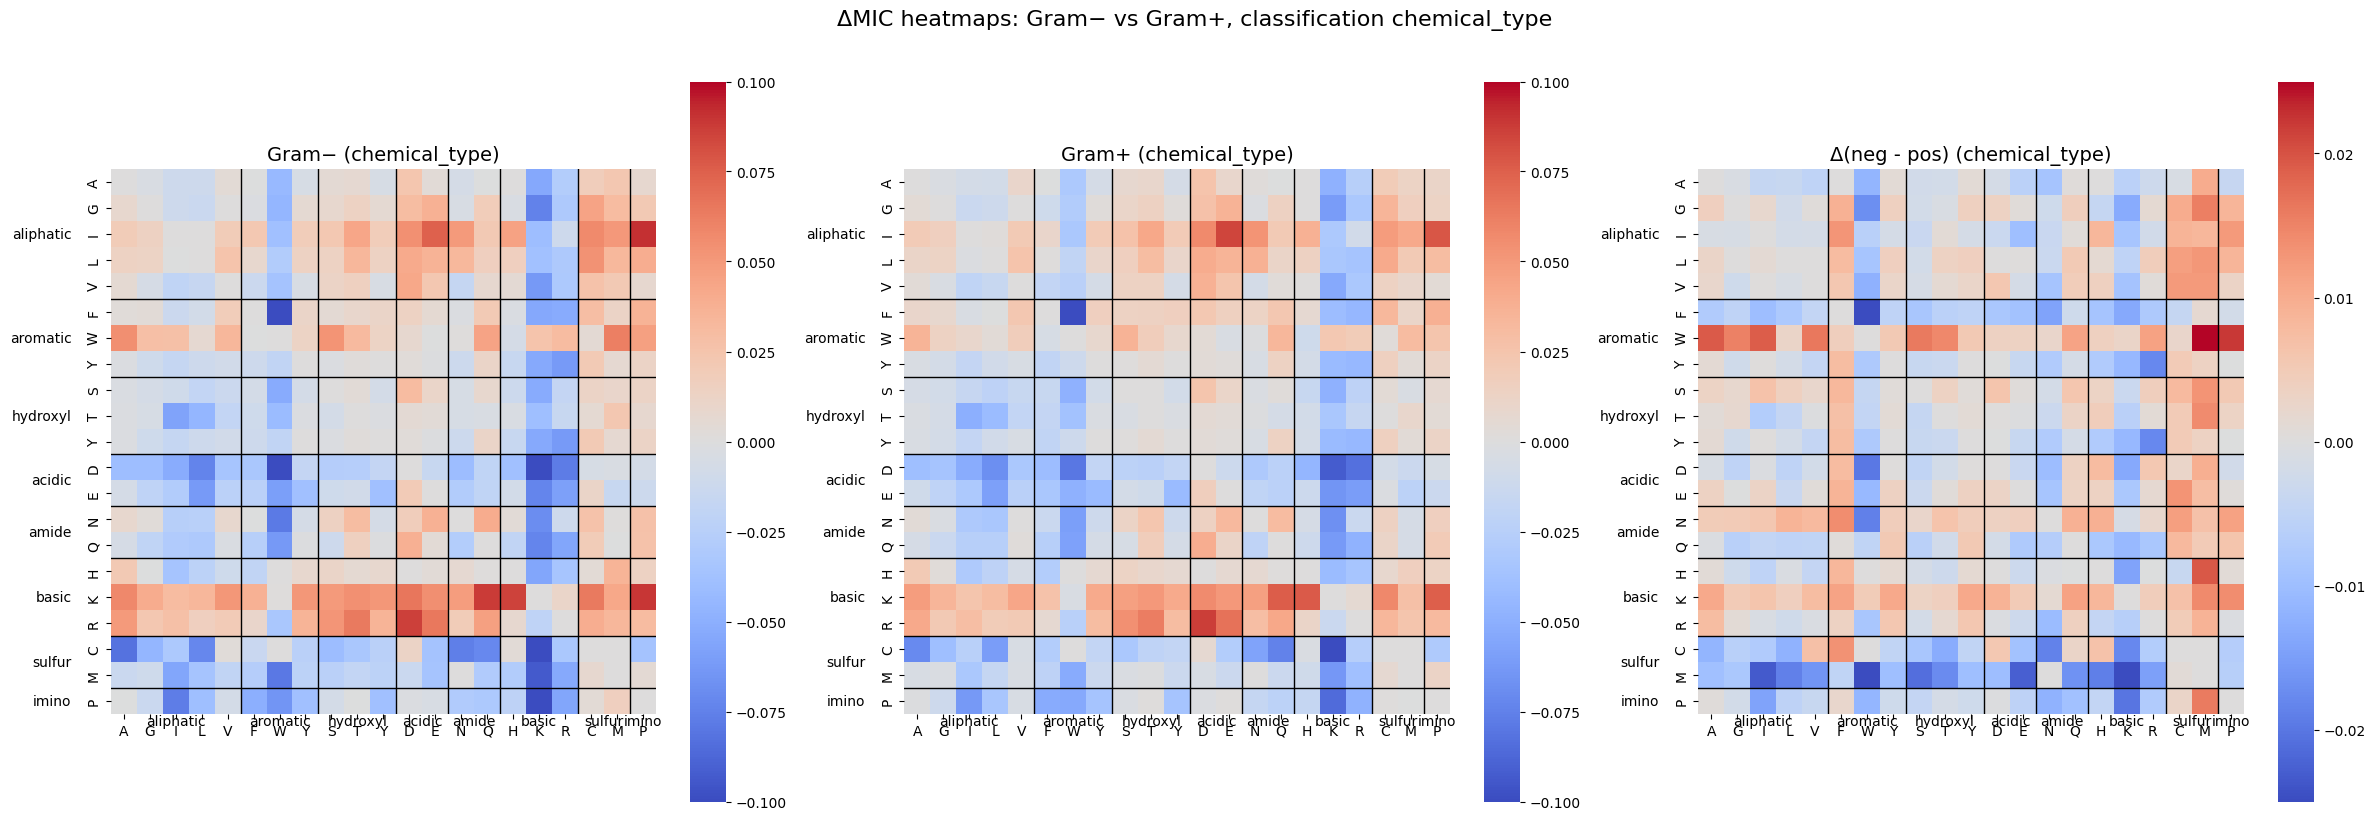

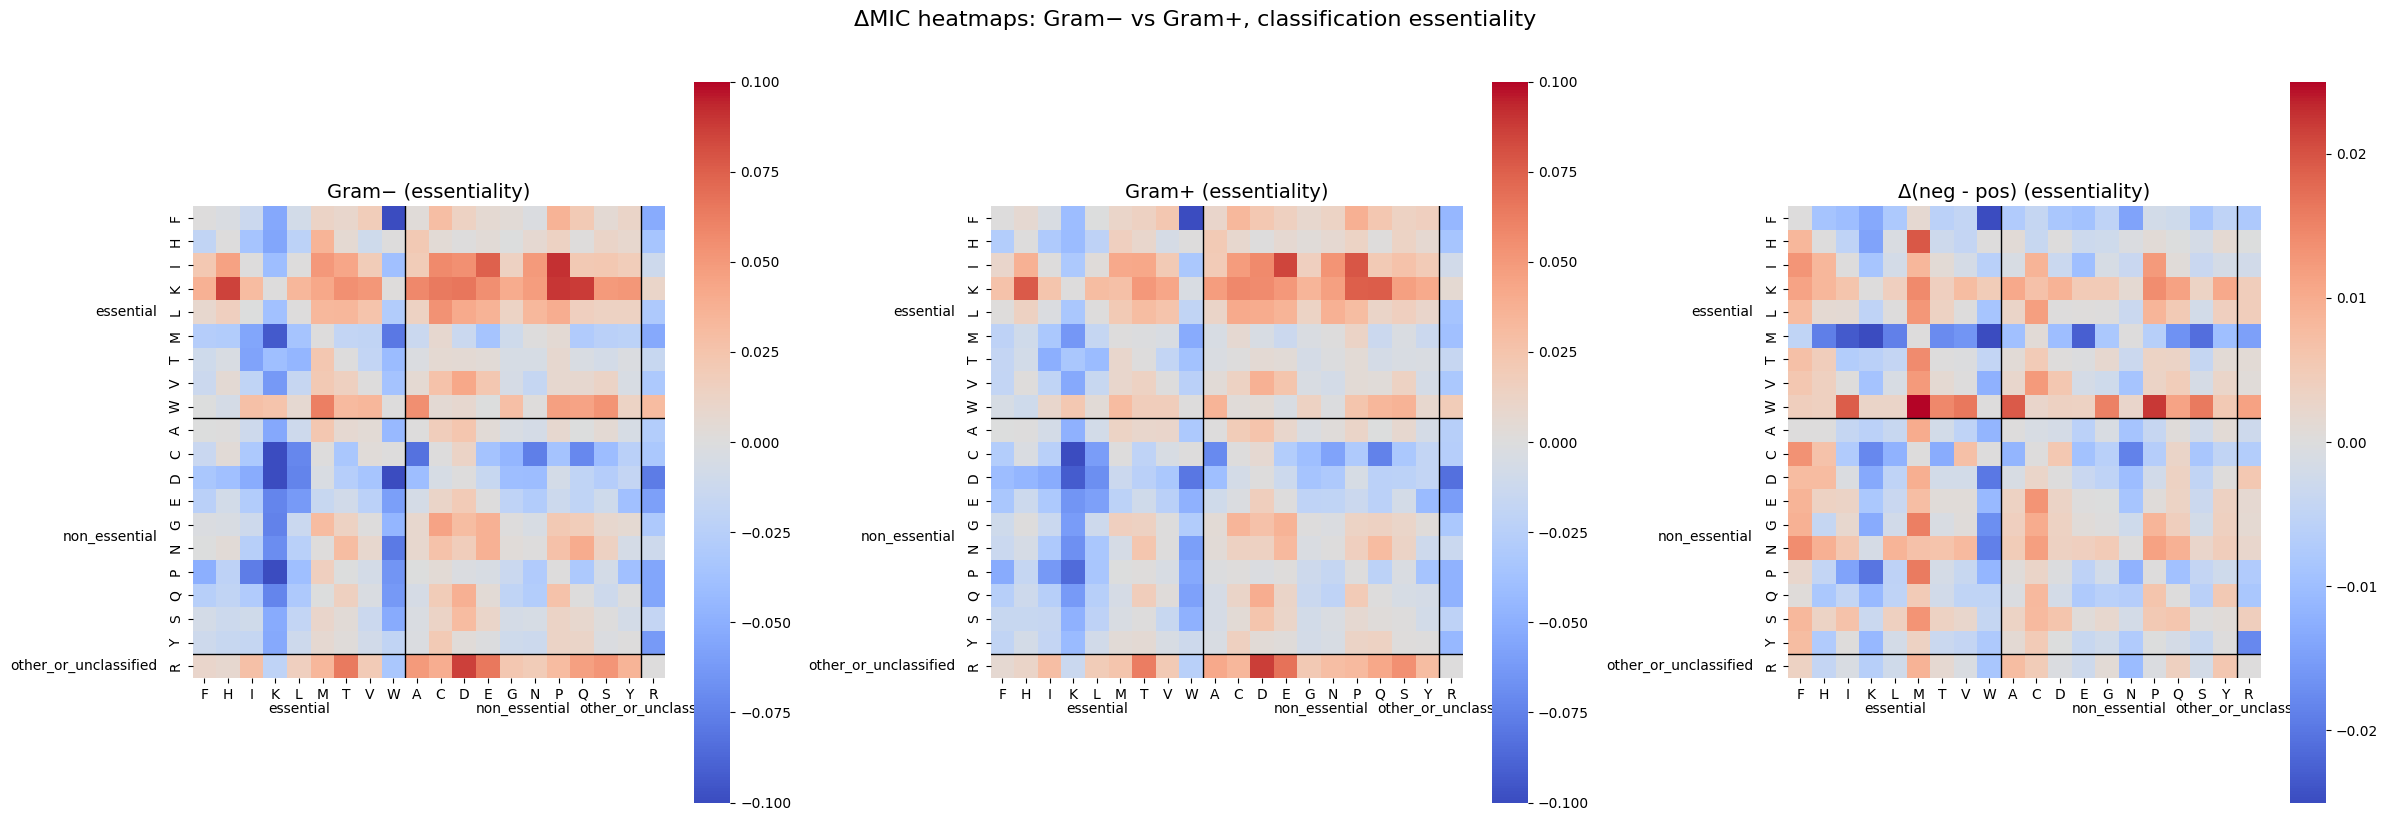

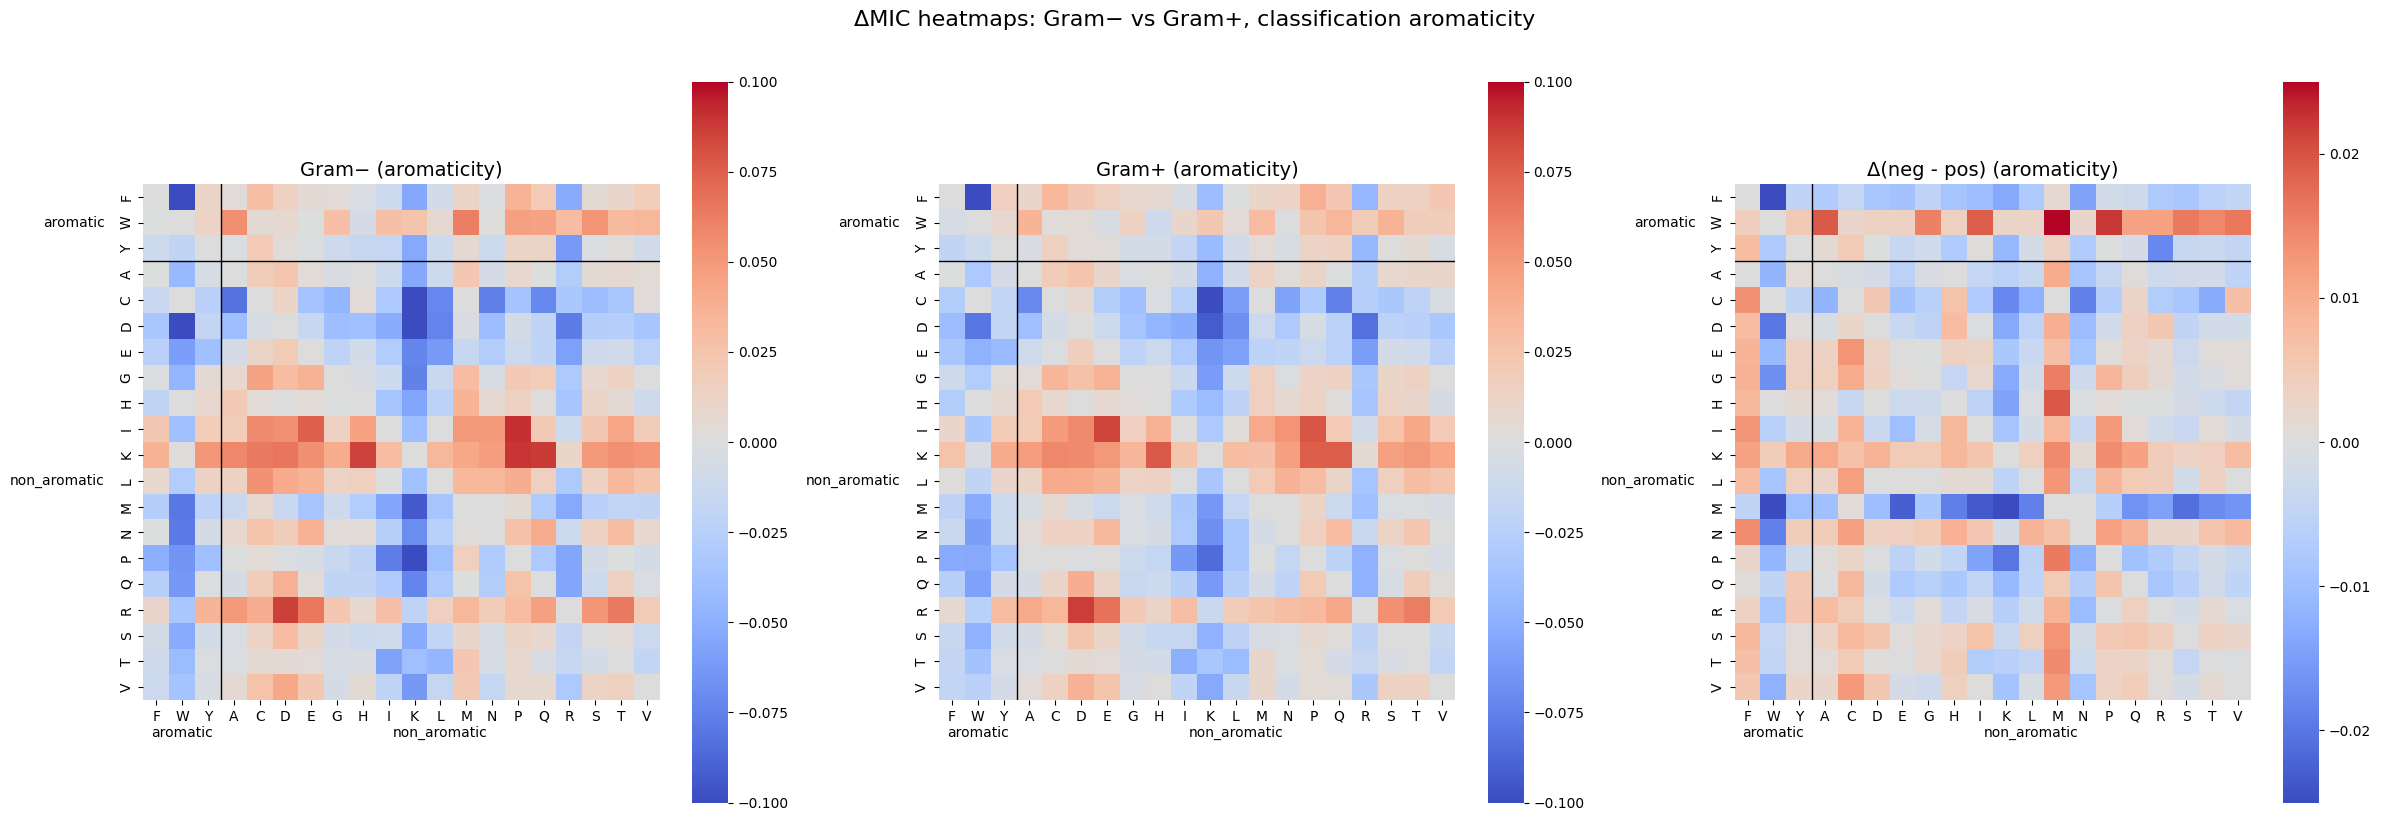

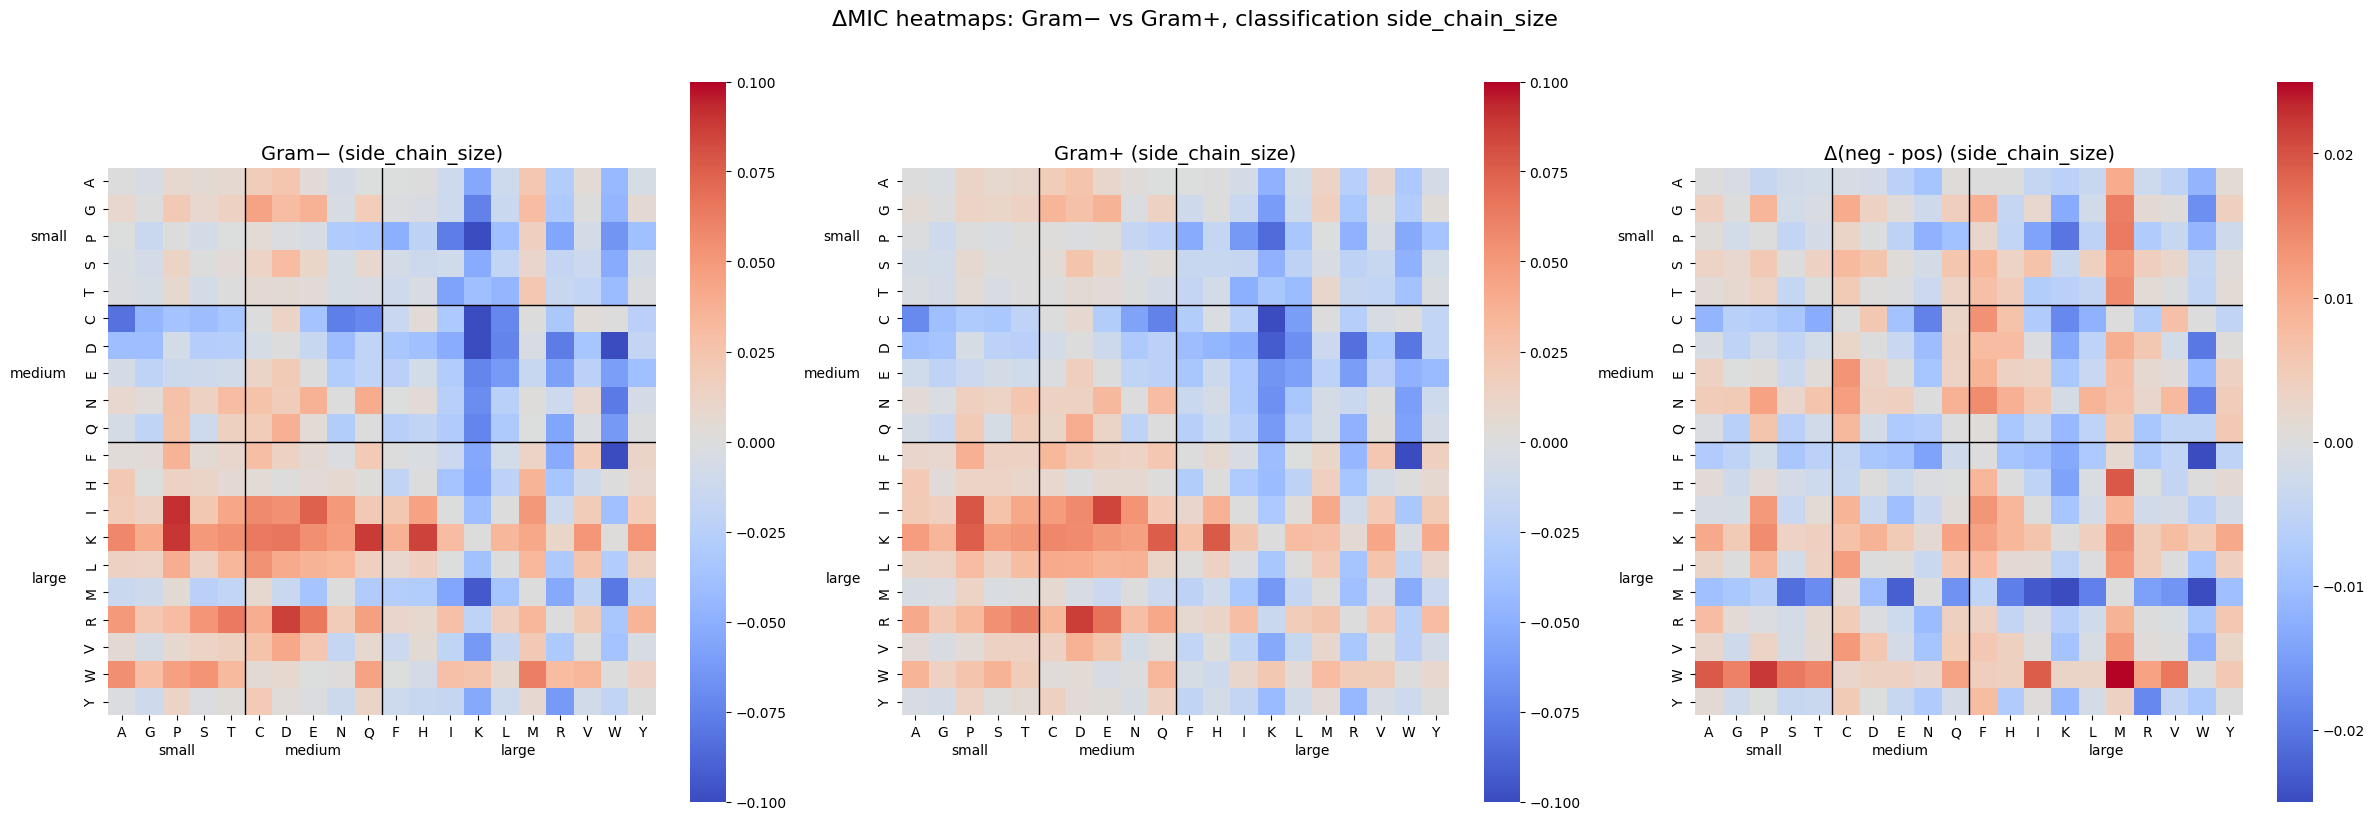

In [22]:
for c in classes:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

    # Draw on given axes instead of creating new ones
    create_square_plot(
        mean_gram_neg_matrix.astype(float),
        classification=c,
        title=f"Gram− ({c})",
        ax=ax1,
        show_labels=True,
        return_fig=False,
        vmin =-0.1,
        vmax=0.1,
    )

    create_square_plot(
        mean_gram_pos_matrix.astype(float),
        classification=c,
        title=f"Gram+ ({c})",
        ax=ax2,
        show_labels=True,
        return_fig=False,
        vmin =-0.1,
        vmax=0.1,
    )

    difference_matrix = mean_gram_neg_matrix - mean_gram_pos_matrix

    create_square_plot(
        difference_matrix.astype(float),
        classification=c,
        title=f"Δ(neg - pos) ({c})",
        ax=ax3,
        show_labels=True,
        return_fig=False,
        vmin=-0.025,
        vmax=0.025,
    )

    fig.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification {c}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
